# 2. Análise exploratória dos dados (EDA)

Este notebook consome **`dados/df_modelo_tratado.csv`**, gerado no notebook **01 (Limpeza e transformação)**.

---

## Olhar de gestão pedagógica (EBTT / ensino técnico federal)

Imagine que você é o **reitor pedagógico** de uma instituição federal de cursos técnicos. Os blocos abaixo respondem, em linguagem direta:

1. **Panorama** — dimensões da base, balanceamento do *target* e **perfil descritivo** das matrículas (sexo, idade, ano, ingresso, etc.), sem condicionar ao desempenho.
2. **Resultado da matrícula** — o que contamos como sucesso ou reprovação (e trancamento/desistência).
3. **Cursos** — quais programas concentram **maior taxa de reprovação** (e volume de matrículas).
4. **Disciplinas e áreas** — componentes e áreas de conhecimento mais críticos.
5. **Currículo** — tipo de carga (aula, laboratório, EaD), natureza do componente.
6. **Organização** — centro e departamento ofertante.
7. **Perfil do discente** — recortes sociodemográficos e de trajetória associados à reprovação.
8. **Evolção no tempo** — tendência anual de matrículas e reprovação.
9. **Base de docentes** — perfil agregado da planilha institucional (complementar ao departamento × ano).
10. **Síntese** — heatmaps e correlações entre variáveis numéricas.

**Interpretação:** taxas são sempre **por matrícula** (cada linha é uma tentativa em disciplina), salvo quando indicamos agregação por curso ou por disciplina. Isso é o que a gestão enxerga como “vulnerabilidade curricular” com volume.

In [32]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

SEED = 42
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# Alinhado ao notebook 01 — para classificar situações nas figuras
SITUACOES_SUCESSO = {
    'APROVADO', 'APROV. C/ DISTINÇÃO', 'DISPENSADO', 'APROVEITADO'
}
SITUACOES_REPROVACAO = {'REPROVADO', 'REP. MEDIA E FALTA', 'REP. FALTA'}
SITUACOES_TRANC_DESIST = {'TRANCADO', 'DESISTENCIA'}

DATA_PATH = 'dados/'
OUTPUT_CSV = DATA_PATH + 'df_modelo_tratado.csv'
df_modelo = pd.read_csv(OUTPUT_CSV, low_memory=False)

# Perfil docentes (opcional — mesma pasta dos Parquets do 01)
try:
    docentes = pd.read_parquet(DATA_PATH + 'docentes.parquet')
except Exception:
    docentes = None

print(df_modelo.shape)
df_modelo.head()

(125764, 47)


,id_discente,id_disciplina,ano,periodo,situacao,status_discente,sexo,ano_nascimento,estado_civil,raca_declarada,...,n_aprov_antes_mesma_area,n_reprov_antes_mesma_area,n_tranc_desist_antes_mesma_area,taxa_sucesso_count_antes_mesma_area,taxa_sucesso_ch_antes_mesma_area,taxa_tranc_desist_count_antes_mesma_area,taxa_tranc_desist_ch_antes_mesma_area,progresso_atual_curso,primeiro_periodo,idade
0,4463581058113,18592,2018,2,APROVADO,CONCLUÍDO,M,2002.0,Solteiro(a),Branca,...,0,0,0,0.0,0.0,0.0,0.0,0.000000,1,16.0
1,4463581058113,18595,2018,2,APROVADO,CONCLUÍDO,M,2002.0,Solteiro(a),Branca,...,0,0,0,0.0,0.0,0.0,0.0,0.029666,1,16.0
2,4463581058113,18598,2018,2,APROVADO,CONCLUÍDO,M,2002.0,Solteiro(a),Branca,...,1,0,0,1.0,1.0,0.0,0.0,0.044499,1,16.0
3,4463581058113,18600,2018,2,APROVADO,CONCLUÍDO,M,2002.0,Solteiro(a),Branca,...,0,0,0,0.0,0.0,0.0,0.0,0.051916,1,16.0
4,4463581058113,18603,2018,2,APROVADO,CONCLUÍDO,M,2002.0,Solteiro(a),Branca,...,0,0,0,0.0,0.0,0.0,0.0,0.081582,1,16.0


## 1. Panorama dos dados

Dimensões principais da base analítica: **matrículas em componentes** com resultado fechado (aprovado, reprovado, trancado, desistência, etc.).

In [33]:
n_lin = len(df_modelo)
n_disc = df_modelo['id_discente'].nunique() if 'id_discente' in df_modelo.columns else None
n_cursos = df_modelo['curso_nome'].nunique() if 'curso_nome' in df_modelo.columns else None
n_comp = df_modelo['id_disciplina'].nunique() if 'id_disciplina' in df_modelo.columns else None

print('--- Panorama ---')
print(f'Matrículas (linhas):     {n_lin:,}')
print(f'Discentes distintos:     {n_disc:,}' if n_disc else '')
print(f'Cursos distintos:        {n_cursos:,}' if n_cursos else '')
print(f'Componentes (disciplinas): {n_comp:,}' if n_comp else '')

if 'target' in df_modelo.columns:
    vc = df_modelo['target'].value_counts()
    print(f"\nTarget: sucesso (1) = {vc.get(1, 0):,} ({vc.get(1, 0) / n_lin * 100:.1f}%) | insucesso (0) = {vc.get(0, 0):,} ({vc.get(0, 0) / n_lin * 100:.1f}%)")
    print('(insucesso inclui reprovação, trancamento e desistência neste recorte — ver notebook 01.)')

cols_show = [c for c in [
    'id_discente', 'curso_nome', 'codigo_componente_curricular', 'area_conhecimento',
    'ano', 'periodo', 'situacao', 'target', 'sexo', 'forma_ingresso', 'media_geral',
    'sigla_centro', 'sigla_departamento'
] if c in df_modelo.columns]
display(df_modelo[cols_show].head(8)) if cols_show else display(df_modelo.head(8))

--- Panorama ---
Matrículas (linhas):     125,764
Discentes distintos:     5,583
Cursos distintos:        21
Componentes (disciplinas): 714

Target: sucesso (1) = 98,255 (78.1%) | insucesso (0) = 27,509 (21.9%)
(insucesso inclui reprovação, trancamento e desistência neste recorte — ver notebook 01.)


,id_discente,curso_nome,codigo_componente_curricular,area_conhecimento,ano,periodo,situacao,target,sexo,forma_ingresso,media_geral,sigla_centro,sigla_departamento
0,4463581058113,TÉCNICO DE NÍVEL MÉDIO EM AGROINDÚSTRIA NA FOR...,TCAVN0001,"Linguística, Letras e Artes",2018,2,APROVADO,1,M,PROCESSO SELETIVO,7.65,CCHSA,CCHSA - CAVN
1,4463581058113,TÉCNICO DE NÍVEL MÉDIO EM AGROINDÚSTRIA NA FOR...,TCAVN0004,Multidisciplinar,2018,2,APROVADO,1,M,PROCESSO SELETIVO,7.65,CCHSA,CCHSA - CAVN
2,4463581058113,TÉCNICO DE NÍVEL MÉDIO EM AGROINDÚSTRIA NA FOR...,TCAVN0007,"Linguística, Letras e Artes",2018,2,APROVADO,1,M,PROCESSO SELETIVO,7.65,CCHSA,CCHSA - CAVN
3,4463581058113,TÉCNICO DE NÍVEL MÉDIO EM AGROINDÚSTRIA NA FOR...,TCAVN0009,Ciências Exatas e da Terra,2018,2,APROVADO,1,M,PROCESSO SELETIVO,7.65,CCHSA,CCHSA - CAVN
4,4463581058113,TÉCNICO DE NÍVEL MÉDIO EM AGROINDÚSTRIA NA FOR...,TCAVN0012,Ciências Biológicas,2018,2,APROVADO,1,M,PROCESSO SELETIVO,7.65,CCHSA,CCHSA - CAVN
5,4463581058113,TÉCNICO DE NÍVEL MÉDIO EM AGROINDÚSTRIA NA FOR...,TCAVN0015,Ciências Exatas e da Terra,2018,2,APROVADO,1,M,PROCESSO SELETIVO,7.65,CCHSA,CCHSA - CAVN
6,4463581058113,TÉCNICO DE NÍVEL MÉDIO EM AGROINDÚSTRIA NA FOR...,TCAVN0018,Ciências Exatas e da Terra,2018,2,APROVADO,1,M,PROCESSO SELETIVO,7.65,CCHSA,CCHSA - CAVN
7,4463581058113,TÉCNICO DE NÍVEL MÉDIO EM AGROINDÚSTRIA NA FOR...,TCAVN0021,Ciências Humanas e Sociais Aplicadas,2018,2,APROVADO,1,M,PROCESSO SELETIVO,7.65,CCHSA,CCHSA - CAVN


### 1.1 Perfil geral das matrículas (descritivo, sem uso do *target*)

Contagens e distribuições “de prontuário”: sexo, cor/raça declarada, forma de ingresso, **idade** na data da matrícula (`ano − ano_nascimento`, quando houver) e **evolução do volume por ano**. Serve como panorama institucional antes das análises condicionadas ao desempenho.

Matrículas por sexo


,n_matriculas,pct
sexo,,
F,70760,56.26
M,54971,43.71
N,33,0.03


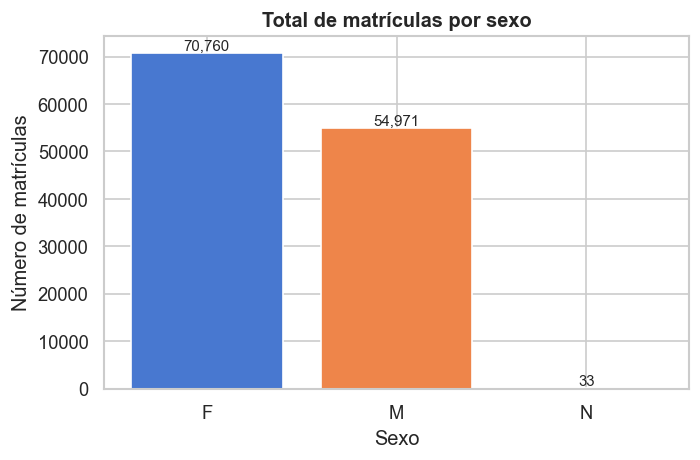

Matrículas por raça/cor declarada


,n_matriculas,pct
raca_declarada,,
Negra,81378,64.71
Branca,27424,21.81
Nao_informado,13537,10.76
Outra,3425,2.72


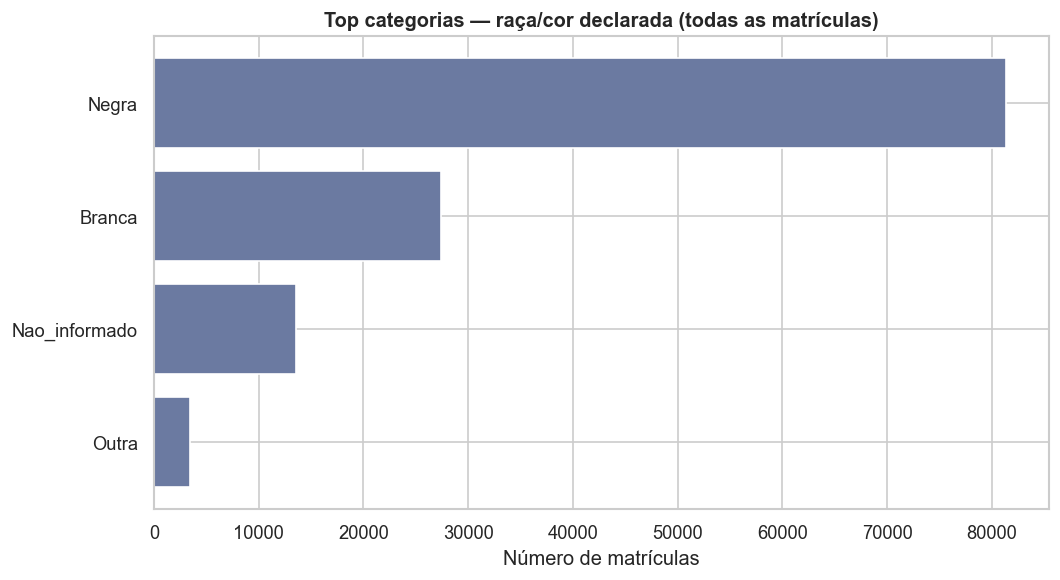

Matrículas por forma de ingresso (top 15)


,n_matriculas,pct
forma_ingresso,,
PROCESSO SELETIVO,124672,99.13
outros,1092,0.87


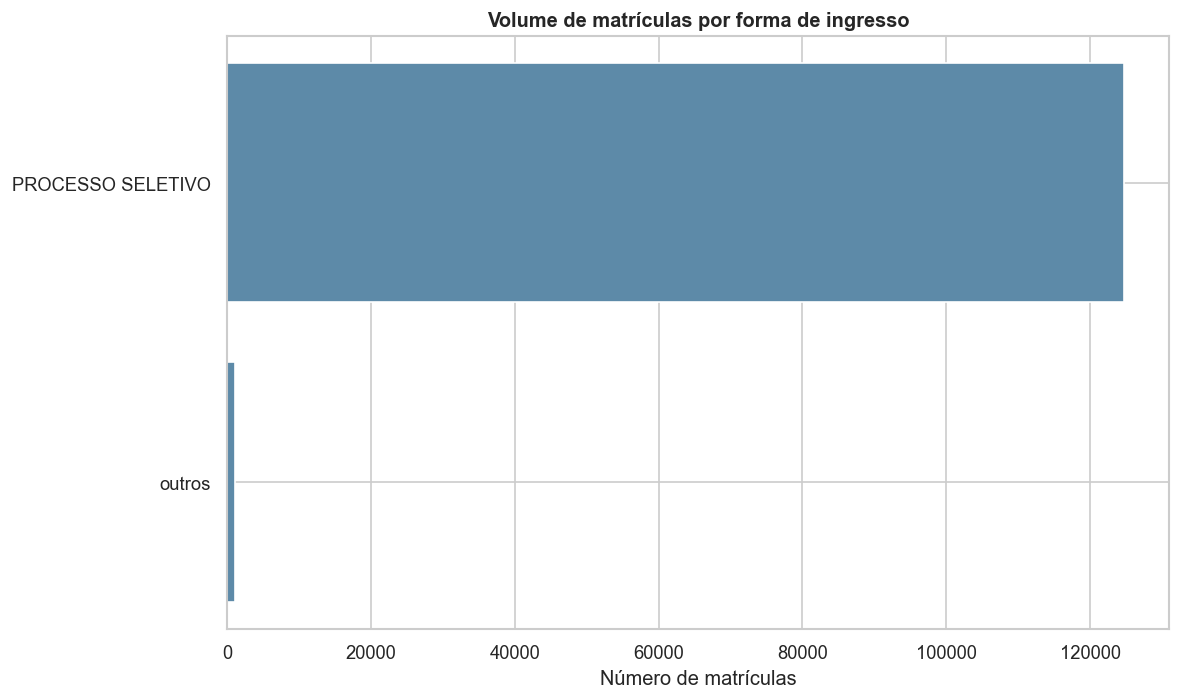

Matrículas por estado civil


,n_matriculas,pct
estado_civil,,
Solteiro(a),103066,81.95
Casado(a),12961,10.31
Outro,9737,7.74


Matrículas por faixa de renda familiar


,n_matriculas,pct
faixa_renda_familiar,,
nulo,70424,56.00
ate_1k,34918,27.76
1k_2k,14705,11.69
2k_4k,4316,3.43
4k_8k,1019,0.81
8k_mais,382,0.30


Matrículas por faixa de membros da família


,n_matriculas,pct
faixa_membros_familia,,
2-3,94505,75.14
4-5,21490,17.09
1,5595,4.45
6+,4174,3.32


Idade (anos) na matrícula — n válidos: 125,764


,count,mean,std,min,25%,50%,75%,max
estatística,125764.0,22.666757,6.612505,12.0,18.0,21.0,26.0,43.0


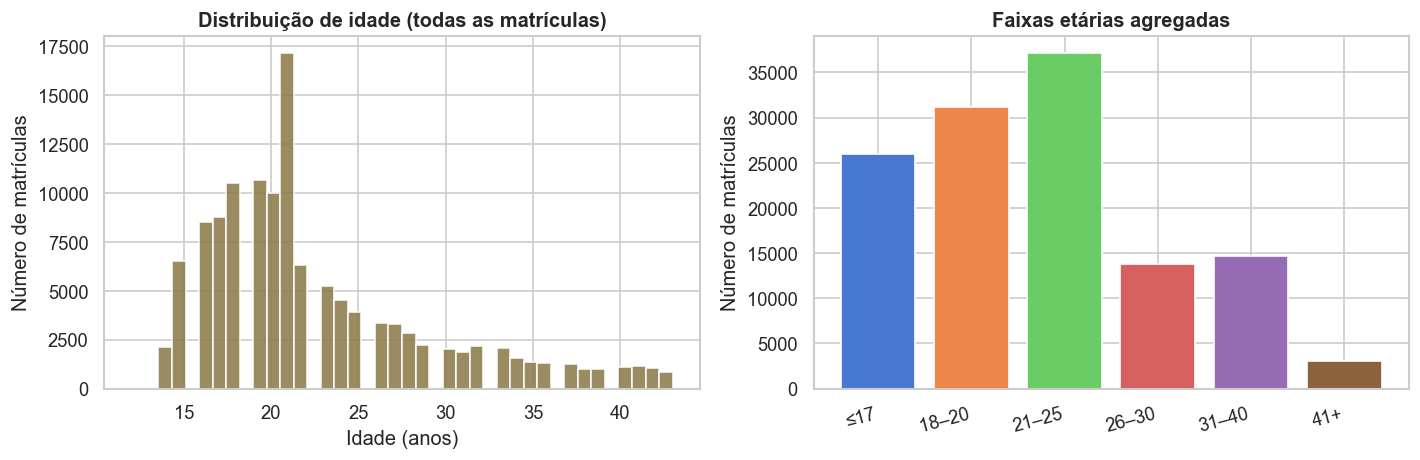

Idade por ano calendário da matrícula (estatísticas)


,n,mediana,media,p25,p75
ano,,,,,
2015,7292,19.0,20.12,17.0,22.0
2016,11231,19.0,21.12,17.0,23.0
2017,13298,19.0,21.02,17.0,23.0
2018,13771,20.0,21.67,18.0,23.0
2019,12654,21.0,22.16,18.0,24.0
2020,11533,21.0,22.82,18.0,26.0
2021,15179,22.0,24.03,19.0,28.0
2022,15121,21.0,23.64,18.0,28.0
2023,16431,21.0,23.44,18.0,27.0


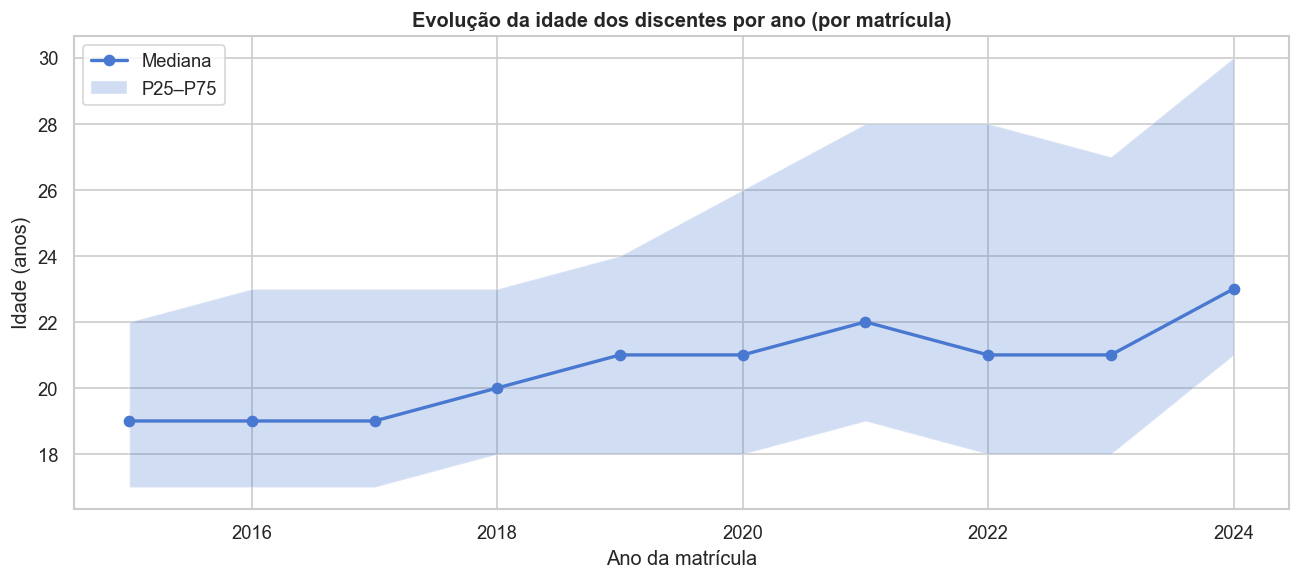

Matrículas por ano


,n_matriculas,pct
ano,,
2015,7292,5.80
2016,11231,8.93
2017,13298,10.57
2018,13771,10.95
2019,12654,10.06
2020,11533,9.17
2021,15179,12.07
2022,15121,12.02
2023,16431,13.06


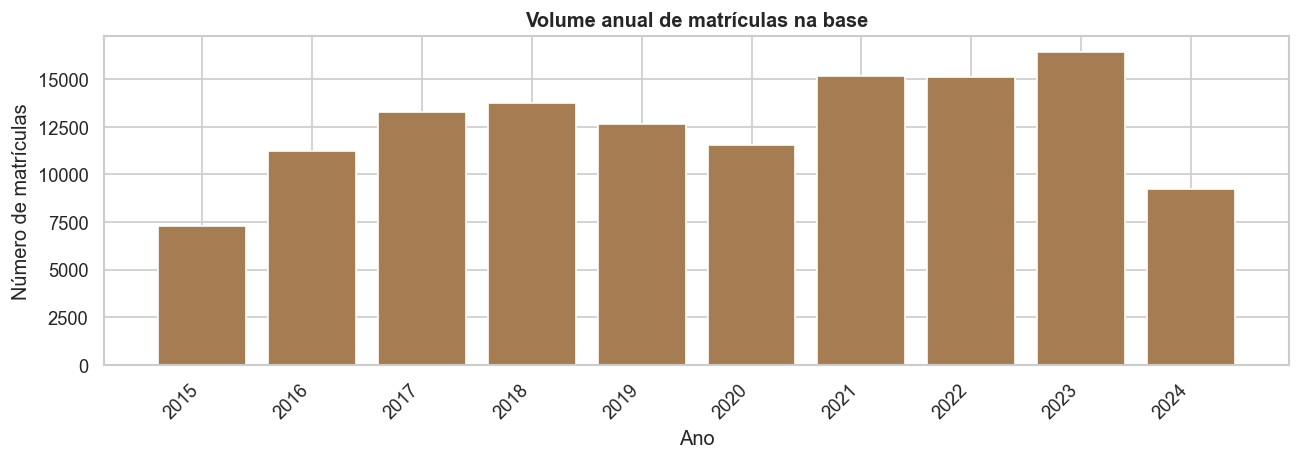

In [34]:
# --- Tabelas e gráficos descritivos (todas as linhas = matrículas)
n = len(df_modelo)

def _pct_serie(s):
    t = s.value_counts(dropna=False)
    return pd.DataFrame({'n_matriculas': t, 'pct': (t / n * 100).round(2)})

if 'sexo' in df_modelo.columns:
    print('Matrículas por sexo')
    display(_pct_serie(df_modelo['sexo']))
    fig, ax = plt.subplots(figsize=(6, 4))
    vc = df_modelo['sexo'].value_counts()
    ax.bar(vc.index.astype(str), vc.values, color=sns.color_palette('muted', len(vc)))
    ax.set_ylabel('Número de matrículas')
    ax.set_xlabel('Sexo')
    ax.set_title('Total de matrículas por sexo', fontweight='bold')
    for i, v in enumerate(vc.values):
        ax.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.savefig('img/fig_panorama_matriculas_sexo.png', dpi=150, bbox_inches='tight')
    plt.show()

if 'raca_declarada' in df_modelo.columns:
    print('Matrículas por raça/cor declarada')
    display(_pct_serie(df_modelo['raca_declarada']))
    fig, ax = plt.subplots(figsize=(9, 5))
    vc = df_modelo['raca_declarada'].value_counts().head(12)
    ax.barh(vc.index.astype(str)[::-1], vc.values[::-1], color='#6B7AA1')
    ax.set_xlabel('Número de matrículas')
    plt.title('Top categorias — raça/cor declarada (todas as matrículas)', fontweight='bold')
    plt.tight_layout()
    plt.savefig('img/fig_panorama_raca.png', dpi=150, bbox_inches='tight')
    plt.show()

if 'forma_ingresso' in df_modelo.columns:
    print('Matrículas por forma de ingresso (top 15)')
    t = _pct_serie(df_modelo['forma_ingresso']).head(15)
    display(t)
    fig, ax = plt.subplots(figsize=(10, 6))
    vc = df_modelo['forma_ingresso'].value_counts().head(15).iloc[::-1]
    ax.barh(vc.index.astype(str).str[:45], vc.values, color='#5D8AA8')
    ax.set_xlabel('Número de matrículas')
    plt.title('Volume de matrículas por forma de ingresso', fontweight='bold')
    plt.tight_layout()
    plt.savefig('img/fig_panorama_ingresso.png', dpi=150, bbox_inches='tight')
    plt.show()

if 'estado_civil' in df_modelo.columns:
    print('Matrículas por estado civil')
    display(_pct_serie(df_modelo['estado_civil']))

if 'faixa_renda_familiar' in df_modelo.columns:
    print('Matrículas por faixa de renda familiar')
    display(_pct_serie(df_modelo['faixa_renda_familiar']))

if 'faixa_membros_familia' in df_modelo.columns:
    print('Matrículas por faixa de membros da família')
    display(_pct_serie(df_modelo['faixa_membros_familia']))

if 'idade' in df_modelo.columns:
    idade = pd.to_numeric(df_modelo['idade'], errors='coerce').dropna()
    print(f'Idade (anos) na matrícula — n válidos: {len(idade):,}')
    if len(idade) > 0:
        display(idade.describe().to_frame('estatística').T)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    if len(idade) == 0:
        for ax in axes:
            ax.text(0.5, 0.5, 'Sem idade válida', ha='center', va='center', transform=ax.transAxes)
    else:
        axes[0].hist(idade, bins=40, color='#8F7E4F', edgecolor='white', alpha=0.9)
        axes[0].set_xlabel('Idade (anos)')
        axes[0].set_ylabel('Número de matrículas')
        axes[0].set_title('Distribuição de idade (todas as matrículas)', fontweight='bold')
        faixas = pd.cut(
            idade,
            bins=[-1, 17, 20, 25, 30, 40, 150],
            labels=['≤17', '18–20', '21–25', '26–30', '31–40', '41+'],
        )
        c = faixas.value_counts().reindex(faixas.cat.categories, fill_value=0)
        axes[1].bar(range(len(c)), c.values, color=sns.color_palette('muted', len(c)))
        axes[1].set_xticks(range(len(c)))
        axes[1].set_xticklabels(c.index.astype(str), rotation=15, ha='right')
        axes[1].set_ylabel('Número de matrículas')
        axes[1].set_title('Faixas etárias agregadas', fontweight='bold')
    plt.tight_layout()
    plt.savefig('img/fig_panorama_idade.png', dpi=150, bbox_inches='tight')
    plt.show()

    if len(idade) > 0 and 'ano' in df_modelo.columns:
        tmp = df_modelo.dropna(subset=['idade', 'ano']).copy()
        tmp['ano'] = pd.to_numeric(tmp['ano'], errors='coerce')
        tmp = tmp.dropna(subset=['ano'])
        tmp['idade'] = pd.to_numeric(tmp['idade'], errors='coerce')
        tmp = tmp.dropna(subset=['idade'])
        resumo_ano = tmp.groupby('ano')['idade'].agg(n='count', mediana='median', media='mean', p25=lambda s: s.quantile(0.25), p75=lambda s: s.quantile(0.75)).round(2)
        if len(resumo_ano) > 0:
            print('Idade por ano calendário da matrícula (estatísticas)')
            display(resumo_ano)
            fig, ax = plt.subplots(figsize=(11, 5))
            ax.plot(resumo_ano.index, resumo_ano['mediana'], 'o-', label='Mediana', lw=2)
            ax.fill_between(resumo_ano.index, resumo_ano['p25'], resumo_ano['p75'], alpha=0.25, label='P25–P75')
            ax.set_xlabel('Ano da matrícula')
            ax.set_ylabel('Idade (anos)')
            ax.legend()
            ax.set_title('Evolução da idade dos discentes por ano (por matrícula)', fontweight='bold')
            plt.tight_layout()
            plt.savefig('img/fig_panorama_idade_por_ano.png', dpi=150, bbox_inches='tight')
            plt.show()

if 'ano' in df_modelo.columns:
    a = pd.to_numeric(df_modelo['ano'], errors='coerce').dropna().astype(int)
    vc_ano = a.value_counts().sort_index()
    print('Matrículas por ano')
    display(pd.DataFrame({'n_matriculas': vc_ano, 'pct': (vc_ano / n * 100).round(2)}))
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.bar(vc_ano.index.astype(str), vc_ano.values, color='#A67C52')
    ax.set_xlabel('Ano')
    ax.set_ylabel('Número de matrículas')
    ax.set_title('Volume anual de matrículas na base', fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('img/fig_panorama_matriculas_ano.png', dpi=150, bbox_inches='tight')
    plt.show()

## 2. Resultado da matrícula (definição do sucesso e da reprovação)

A variável **`target`** resume o desempenho em **sucesso (1)** versus **insucesso (0)**. Para políticas específicas de **reprovação estrita**, isolamos também as situações de nota/falta.

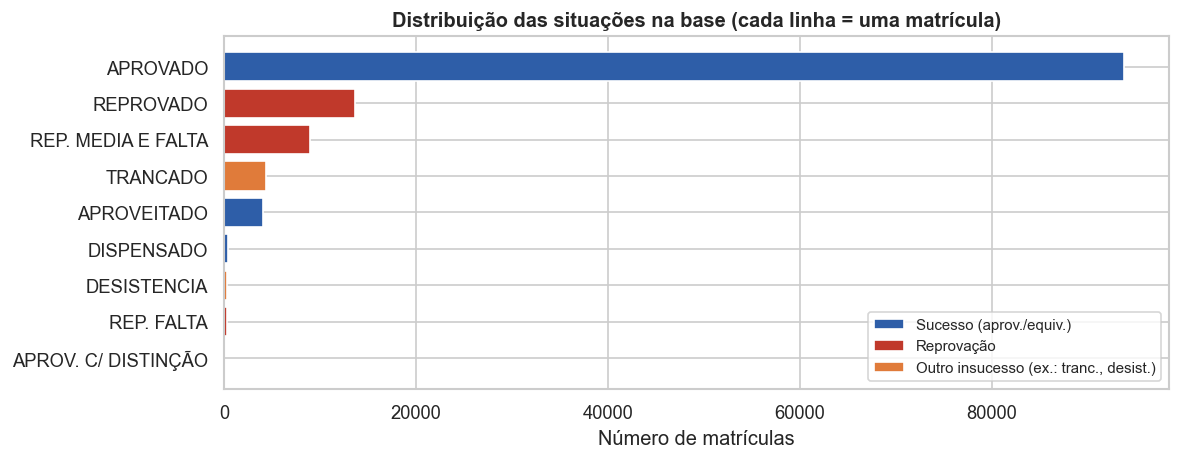

Matrículas com reprovação (nota/falta): 22,872 (18.2% do total)


In [35]:
if 'situacao' in df_modelo.columns:
    sit = df_modelo['situacao'].value_counts()
    fig, ax = plt.subplots(figsize=(10, max(4, len(sit) * 0.22)))
    colors_map = ['#2E5EA8' if s in SITUACOES_SUCESSO else '#C0392B' if s in SITUACOES_REPROVACAO else '#E07B3A' for s in sit.index]
    ax.barh(sit.index[::-1], sit.values[::-1], color=colors_map[::-1])
    ax.set_xlabel('Número de matrículas')
    ax.set_title('Distribuição das situações na base (cada linha = uma matrícula)', fontweight='bold')
    ax.legend(handles=[
        Patch(facecolor='#2E5EA8', label='Sucesso (aprov./equiv.)'),
        Patch(facecolor='#C0392B', label='Reprovação'),
        Patch(facecolor='#E07B3A', label='Outro insucesso (ex.: tranc., desist.)'),
    ], loc='lower right', fontsize=9)
    plt.tight_layout()
    plt.savefig('img/fig0_distrib_situacoes.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Taxa de reprovação estrita (só REPROVADO / REP...)
    mask_rep = df_modelo['situacao'].isin(SITUACOES_REPROVACAO)
    print(f"Matrículas com reprovação (nota/falta): {mask_rep.sum():,} ({mask_rep.mean()*100:.1f}% do total)")

## 3. Cursos: maiores taxas de reprovação e volume

Agregamos por **`curso_nome`**. Exigimos um **mínimo de matrículas** por curso para não destacar cursos com pouquíssimas tentativas. Métricas: **taxa de insucesso** (`1 - média(target)`) e **taxa de reprovação estrita** (somente situações de reprovação).

,curso_nome,n,taxa_sucesso,taxa_reprovacao_estrita,taxa_insucesso_pct,taxa_reprovacao_estrita_pct
20,TÉCNICO EM SAÚDE BUCAL,255,0.53,0.43,47.45,42.75
10,TÉCNICO DE NÍVEL MÉDIO EM PAISAGISMO NA FORMA ...,1908,0.59,0.33,40.88,32.81
19,TÉCNICO EM REGISTROS E INFORMAÇÕES EM SAÚDE - EaD,4038,0.60,0.36,39.72,36.11
8,TÉCNICO DE NÍVEL MÉDIO EM LABORATÓRIO DE CIÊNC...,1217,0.65,0.27,34.84,27.36
3,TÉCNICO DE NÍVEL MÉDIO EM AGROPECUÁRIA - INTEG...,4507,0.66,0.30,34.30,30.46
6,TÉCNICO DE NÍVEL MÉDIO EM AQUICULTURA NA FORMA...,4288,0.66,0.30,34.28,29.87
14,TÉCNICO EM CITOPATOLOGIA,308,0.67,0.32,33.12,32.14
11,TÉCNICO DE NÍVEL MÉDIO EM VETERINÁRIA NA FORMA...,1908,0.71,0.19,29.45,19.03
12,TÉCNICO EM AGENTE COMUNITÁRIO DE SAÚDE,830,0.72,0.28,27.83,27.83
5,TÉCNICO DE NÍVEL MÉDIO EM AGROPECUÁRIA NA FORM...,13804,0.75,0.20,24.69,19.60


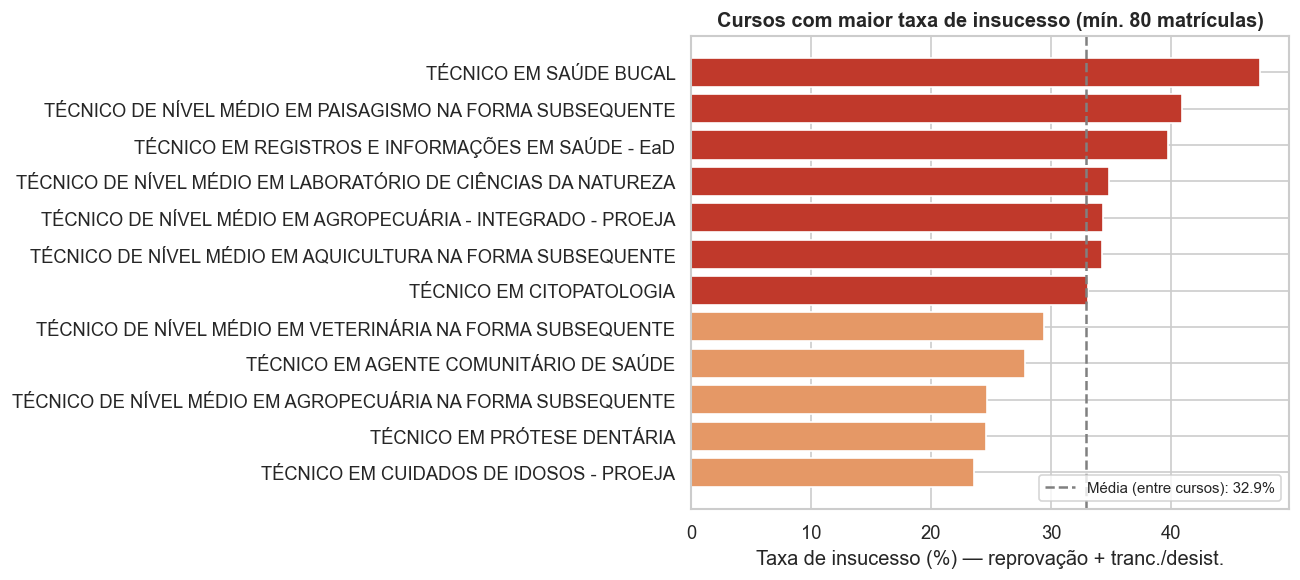

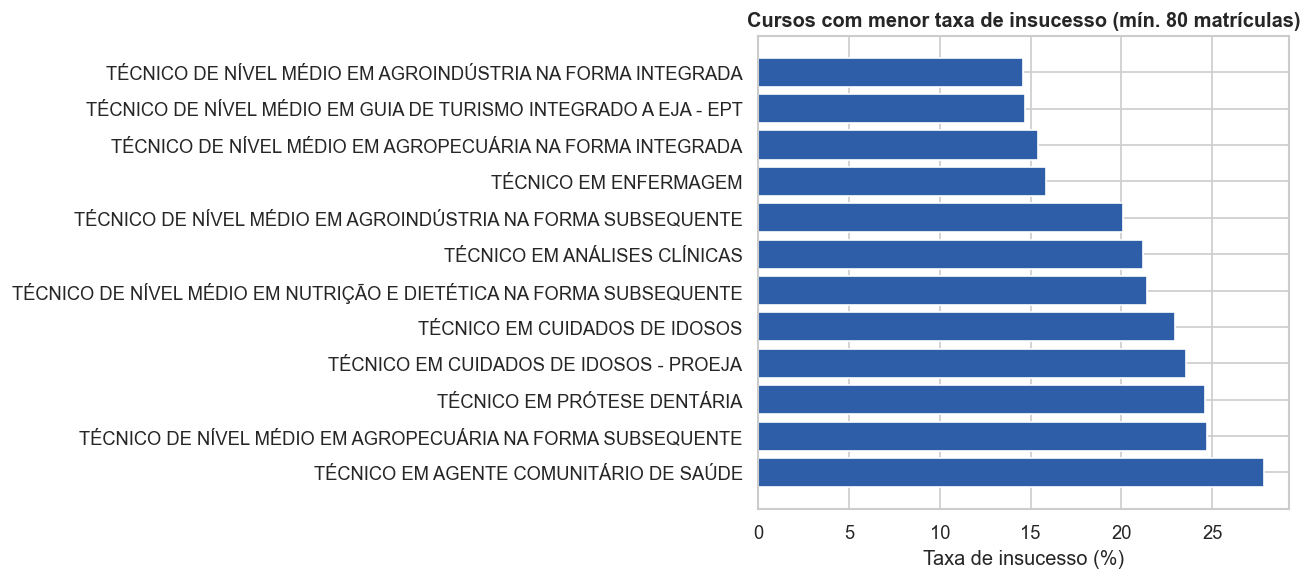

In [36]:
MIN_MATRICULAS_CURSO = 80

if {'curso_nome', 'target', 'situacao'}.issubset(df_modelo.columns):
    g = df_modelo.groupby('curso_nome').agg(
        n=('target', 'count'),
        taxa_sucesso=('target', 'mean'),
        taxa_reprovacao_estrita=('situacao', lambda s: s.isin(SITUACOES_REPROVACAO).mean()),
    ).reset_index()
    g = g[g['n'] >= MIN_MATRICULAS_CURSO].copy()
    g['taxa_insucesso_pct'] = (1 - g['taxa_sucesso']) * 100
    g['taxa_reprovacao_estrita_pct'] = g['taxa_reprovacao_estrita'] * 100
    g = g.sort_values('taxa_insucesso_pct', ascending=False)

    display(g.head(15).round(2))

    top_k = 12
    worst = g.head(top_k).iloc[::-1]
    fig, ax = plt.subplots(figsize=(11, max(5, top_k * 0.35)))
    x = worst['taxa_insucesso_pct'].values
    colors = ['#C0392B' if v >= x.mean() else '#E59866' for v in x]
    ax.barh(worst['curso_nome'].str[:70], worst['taxa_insucesso_pct'].values, color=colors)
    ax.axvline(x.mean(), color='gray', linestyle='--', label=f'Média (entre cursos): {x.mean():.1f}%')
    ax.set_xlabel('Taxa de insucesso (%) — reprovação + tranc./desist.')
    ax.set_title(f'Cursos com maior taxa de insucesso (mín. {MIN_MATRICULAS_CURSO} matrículas)', fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    plt.tight_layout()
    plt.savefig('img/fig_cursos_maior_insucesso.png', dpi=150, bbox_inches='tight')
    plt.show()

    best = g.sort_values('taxa_insucesso_pct').head(top_k).iloc[::-1]
    fig, ax = plt.subplots(figsize=(11, max(5, top_k * 0.35)))
    ax.barh(best['curso_nome'].str[:70], best['taxa_insucesso_pct'], color='#2E5EA8')
    ax.set_xlabel('Taxa de insucesso (%)')
    ax.set_title(f'Cursos com menor taxa de insucesso (mín. {MIN_MATRICULAS_CURSO} matrículas)', fontweight='bold')
    plt.tight_layout()
    plt.savefig('img/fig_cursos_menor_insucesso.png', dpi=150, bbox_inches='tight')
    plt.show()

## 4. Disciplinas (componentes) e áreas de conhecimento

Agregação por **nome do componente curricular** (`nome_componete_curricular`). Identificamos os componentes com maior **insucesso** e maior **reprovação estrita**, com piso de **n** matrículas para estabilidade estatística.

,nome_componete_curricular,n,taxa_sucesso,taxa_rep_estrita,taxa_insucesso_pct,taxa_rep_estrita_pct,area
353,LÍNGUA PORTUGUESA - 1º ANO - PROEJA,126,0.40,0.53,59.52,53.17,"Linguística, Letras e Artes"
544,SOCIOLOGIA - 1º ANO - PROEJA,131,0.41,0.53,58.78,52.67,Ciências Humanas e Sociais Aplicadas
293,INFORMÁTICA - 1º ANO - PROEJA,124,0.42,0.52,58.06,51.61,Tecnologia da Informação
505,QUÍMICA - 1º ANO - PROEJA,128,0.42,0.52,57.81,51.56,Ciências Exatas e da Terra
225,FÍSICA - 1º ANO - PROEJA,125,0.42,0.51,57.60,51.20,Ciências Exatas e da Terra
368,MATEMÁTICA - 1º ANO - PROEJA,122,0.43,0.50,56.56,50.00,Ciências Exatas e da Terra
45,BIOLOGIA - 1º ANO - PROEJA,125,0.44,0.50,56.00,49.60,Ciências Biológicas
345,LINGUAGEM VISUAL,123,0.46,0.46,54.47,45.53,"Linguística, Letras e Artes"
236,GEOGRAFIA - 1º ANO - PROEJA,125,0.46,0.48,54.40,48.00,Ciências Humanas e Sociais Aplicadas
166,ESTUDO DAS PLANTAS ORNAMENTAIS,129,0.46,0.43,54.26,43.41,Ciências Agrárias


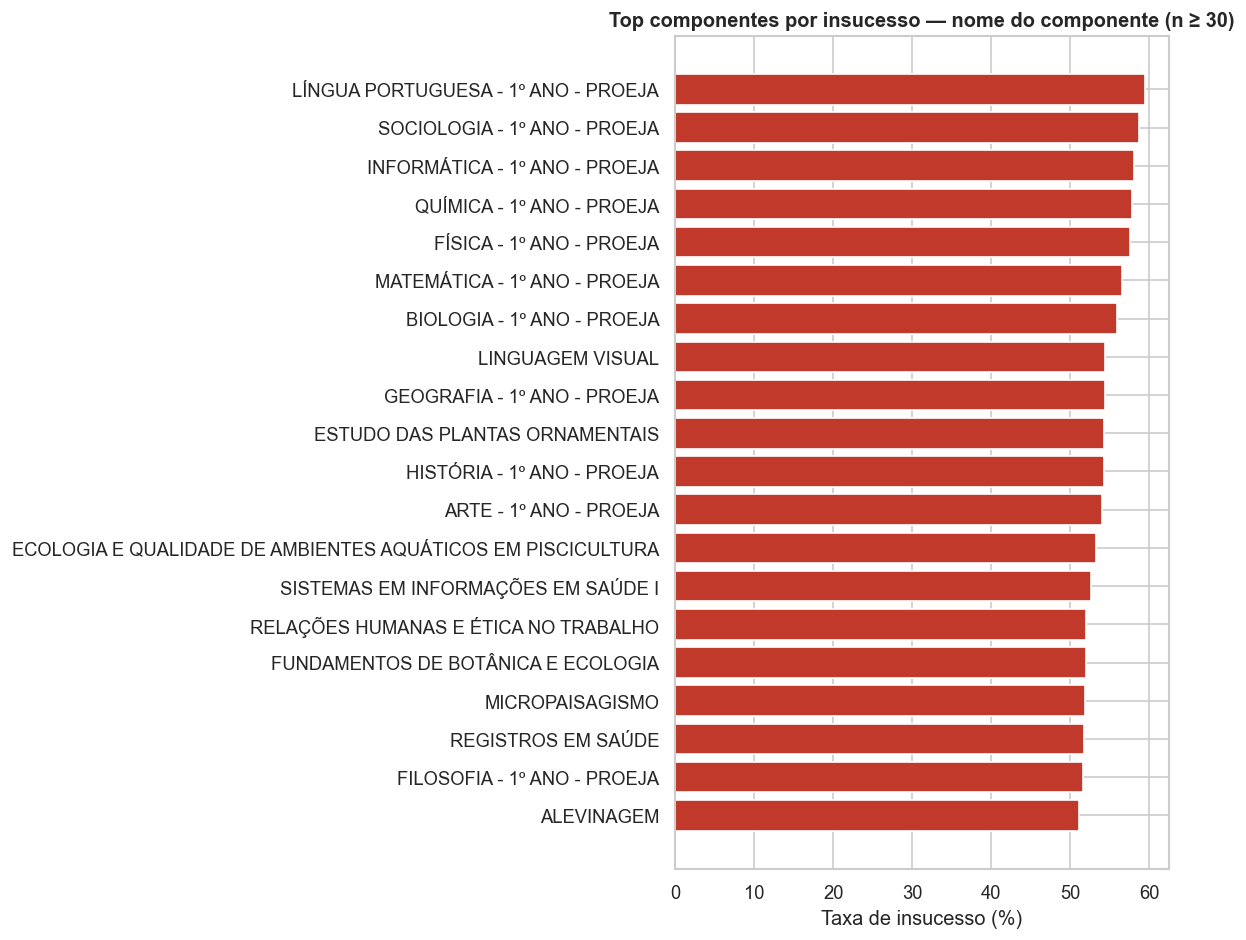

,area_conhecimento,n,taxa_sucesso,taxa_insucesso_pct
7,Tecnologia da Informação,3544,0.70,29.88
4,Ciências da Saúde,33599,0.77,23.21
1,Ciências Biológicas,8836,0.77,23.01
0,Ciências Agrárias,34315,0.77,23.00
3,Ciências Humanas e Sociais Aplicadas,19600,0.79,21.43
2,Ciências Exatas e da Terra,8073,0.79,21.37
5,"Linguística, Letras e Artes",6333,0.81,19.25
6,Multidisciplinar,11464,0.86,13.78


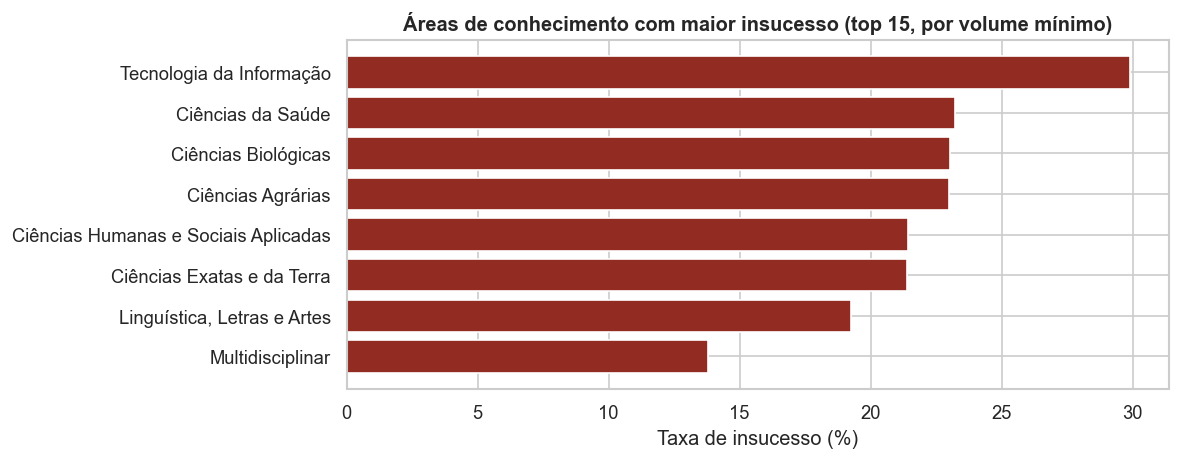

In [37]:
MIN_N_DISC = 30

def _modo_series(s):
    m = s.mode()
    return m.iloc[0] if len(m) else s.iloc[0]

if {'nome_componete_curricular', 'target', 'situacao'}.issubset(df_modelo.columns):
    comp = (
        df_modelo.groupby('nome_componete_curricular')['target']
        .agg(n='count', taxa_sucesso='mean')
        .join(
            df_modelo.groupby('nome_componete_curricular')['situacao'].apply(
                lambda s: s.isin(SITUACOES_REPROVACAO).mean()
            ).rename('taxa_rep_estrita')
        )
        .reset_index()
    )
    comp = comp[comp['n'] >= MIN_N_DISC].copy()
    comp['taxa_insucesso_pct'] = (1 - comp['taxa_sucesso']) * 100
    comp['taxa_rep_estrita_pct'] = comp['taxa_rep_estrita'] * 100

    if 'area_conhecimento' in df_modelo.columns:
        area_map = df_modelo.groupby('nome_componete_curricular')['area_conhecimento'].agg(_modo_series)
        comp['area'] = comp['nome_componete_curricular'].map(area_map)

    worst_d = comp.nlargest(20, 'taxa_insucesso_pct')
    display(worst_d.round(2))

    lab = worst_d['nome_componete_curricular'].astype(str).str[:60]
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(lab.iloc[::-1], worst_d['taxa_insucesso_pct'].iloc[::-1], color='#C0392B')
    ax.set_xlabel('Taxa de insucesso (%)')
    ax.set_title(f'Top componentes por insucesso — nome do componente (n ≥ {MIN_N_DISC})', fontweight='bold')
    plt.tight_layout()
    plt.savefig('img/fig_disciplinas_maior_insucesso.png', dpi=150, bbox_inches='tight')
    plt.show()

if 'area_conhecimento' in df_modelo.columns:
    ga = df_modelo.groupby('area_conhecimento').agg(
        n=('target', 'count'),
        taxa_sucesso=('target', 'mean'),
    ).reset_index()
    ga = ga[ga['n'] >= MIN_N_DISC].copy()
    ga['taxa_insucesso_pct'] = (1 - ga['taxa_sucesso']) * 100
    ga = ga.sort_values('taxa_insucesso_pct', ascending=False)
    display(ga.head(15).round(2))

    fig, ax = plt.subplots(figsize=(10, max(4, min(15, len(ga)) * 0.35)))
    plot_g = ga.head(15).iloc[::-1]
    ax.barh(plot_g['area_conhecimento'].astype(str).str[:55], plot_g['taxa_insucesso_pct'], color='#922B21')
    ax.set_xlabel('Taxa de insucesso (%)')
    ax.set_title('Áreas de conhecimento com maior insucesso (top 15, por volume mínimo)', fontweight='bold')
    plt.tight_layout()
    plt.savefig('img/fig_areas_insucesso.png', dpi=150, bbox_inches='tight')
    plt.show()

## 5. Estrutura curricular: tipo de componente e carga horária

Como se distribui o **sucesso** quando mudamos a **natureza** do componente (tipo de disciplina, descrição do tipo) e a **composição** da CH (aula, laboratório, EaD)?

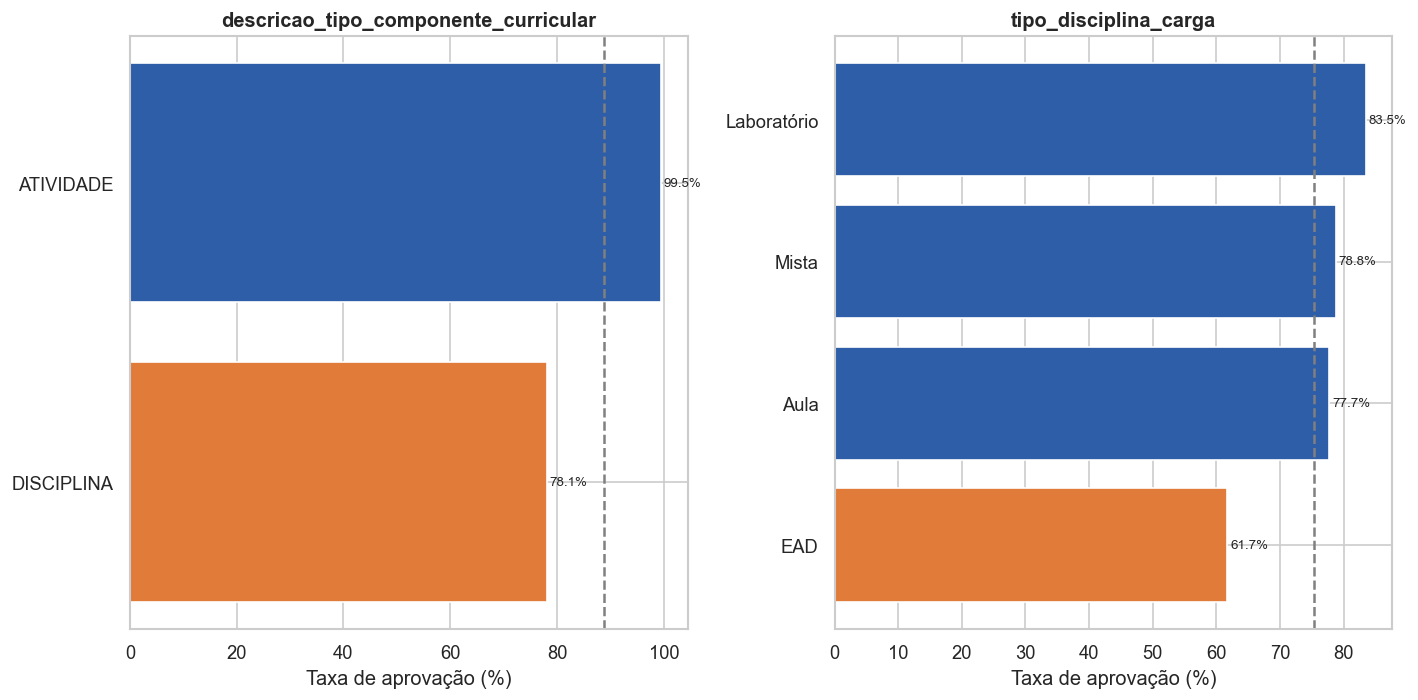

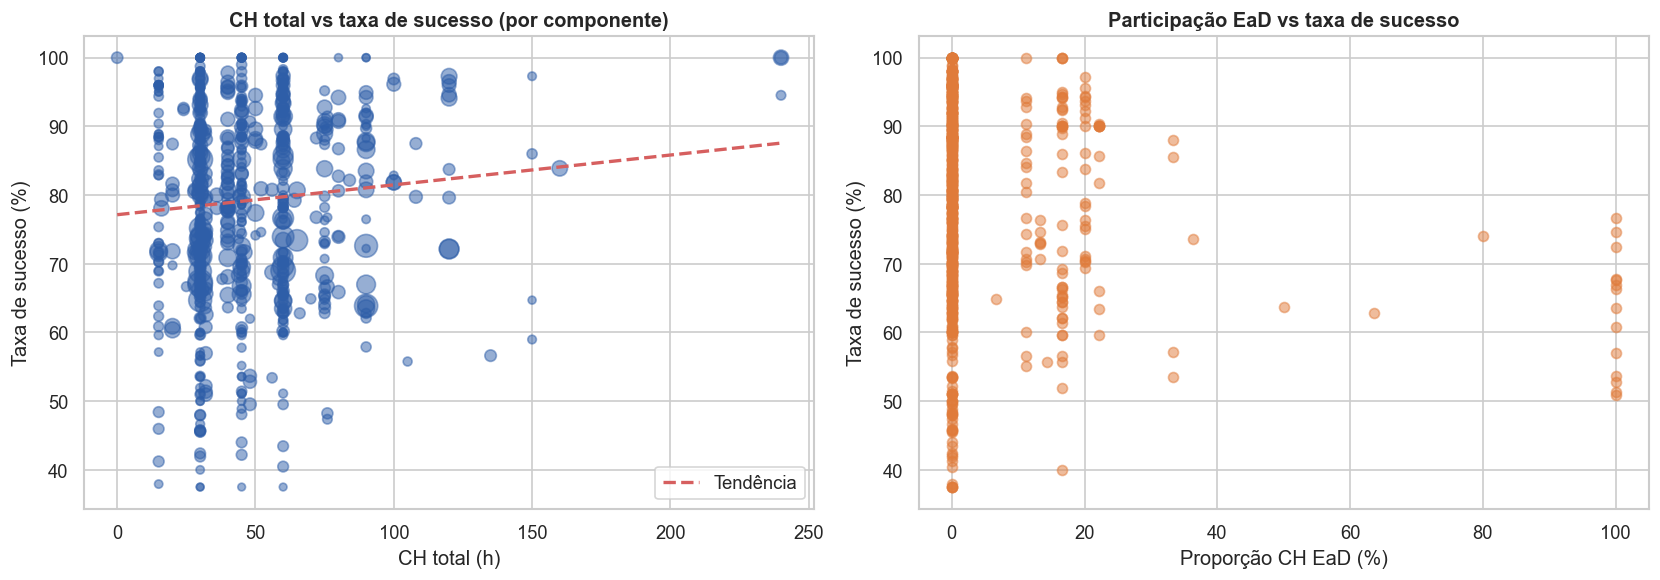

In [38]:
cols_curr = [c for c in [
    'descricao_tipo_componente_curricular',
    'tipo_disciplina_carga',
] if c in df_modelo.columns]
if cols_curr:
    fig, axes = plt.subplots(1, len(cols_curr), figsize=(6 * len(cols_curr), 6))
    if len(cols_curr) == 1:
        axes = [axes]
    for ax, col in zip(axes, cols_curr):
        taxa = df_modelo.groupby(col)['target'].mean().sort_values() * 100
        taxa = taxa.head(15)
        colors = ['#2E5EA8' if v >= taxa.mean() else '#E07B3A' for v in taxa.values]
        bars = ax.barh(taxa.index.astype(str).str[:50], taxa.values, color=colors)
        ax.axvline(taxa.mean(), color='gray', linestyle='--')
        ax.set_xlabel('Taxa de aprovação (%)')
        ax.set_title(col[:60], fontweight='bold')
        for bar, val in zip(bars, taxa.values):
            ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2, f'{val:.1f}%', va='center', fontsize=8)
    plt.tight_layout()
    plt.savefig('img/fig5_taxa_sucesso_curriculo.png', dpi=150, bbox_inches='tight')
    plt.show()

if {'id_disciplina', 'ch_total', 'ch_ead', 'target'}.issubset(df_modelo.columns):
    comp_taxa = df_modelo.groupby('id_disciplina').agg(
        taxa_sucesso=('target', 'mean'), ch_total=('ch_total', 'first'),
        ch_ead=('ch_ead', 'first'), total=('target', 'count')
    ).reset_index()
    comp_taxa = comp_taxa[comp_taxa['total'] >= 5]
    comp_taxa['prop_ead'] = comp_taxa['ch_ead'] / (comp_taxa['ch_total'] + 1e-6)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].scatter(comp_taxa['ch_total'], comp_taxa['taxa_sucesso'] * 100, alpha=0.5,
                    s=comp_taxa['total'] / comp_taxa['total'].max() * 200 + 20, color='#2E5EA8')
    valid = comp_taxa[['ch_total', 'taxa_sucesso']].dropna()
    if len(valid) > 1:
        p = np.poly1d(np.polyfit(valid['ch_total'], valid['taxa_sucesso'] * 100, 1))
        xl = np.linspace(valid['ch_total'].min(), valid['ch_total'].max(), 100)
        axes[0].plot(xl, p(xl), 'r--', lw=2, label='Tendência')
    axes[0].set_xlabel('CH total (h)')
    axes[0].set_ylabel('Taxa de sucesso (%)')
    axes[0].set_title('CH total vs taxa de sucesso (por componente)', fontweight='bold')
    axes[0].legend()

    axes[1].scatter(comp_taxa['prop_ead'] * 100, comp_taxa['taxa_sucesso'] * 100, alpha=0.5, color='#E07B3A')
    axes[1].set_xlabel('Proporção CH EaD (%)')
    axes[1].set_ylabel('Taxa de sucesso (%)')
    axes[1].set_title('Participação EaD vs taxa de sucesso', fontweight='bold')
    plt.tight_layout()
    plt.savefig('img/fig6_ch_vs_taxa.png', dpi=150, bbox_inches='tight')
    plt.show()

## 6. Organização acadêmica: centro e departamento

Recorte por **`sigla_centro`** e **`sigla_departamento`** ajuda a priorizar apoio pedagógico e revisão de oferta.

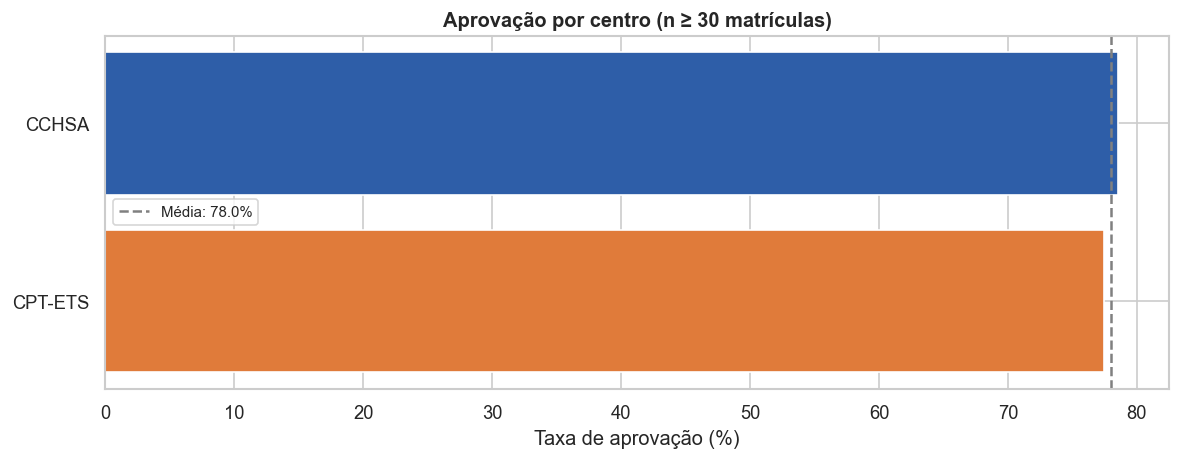

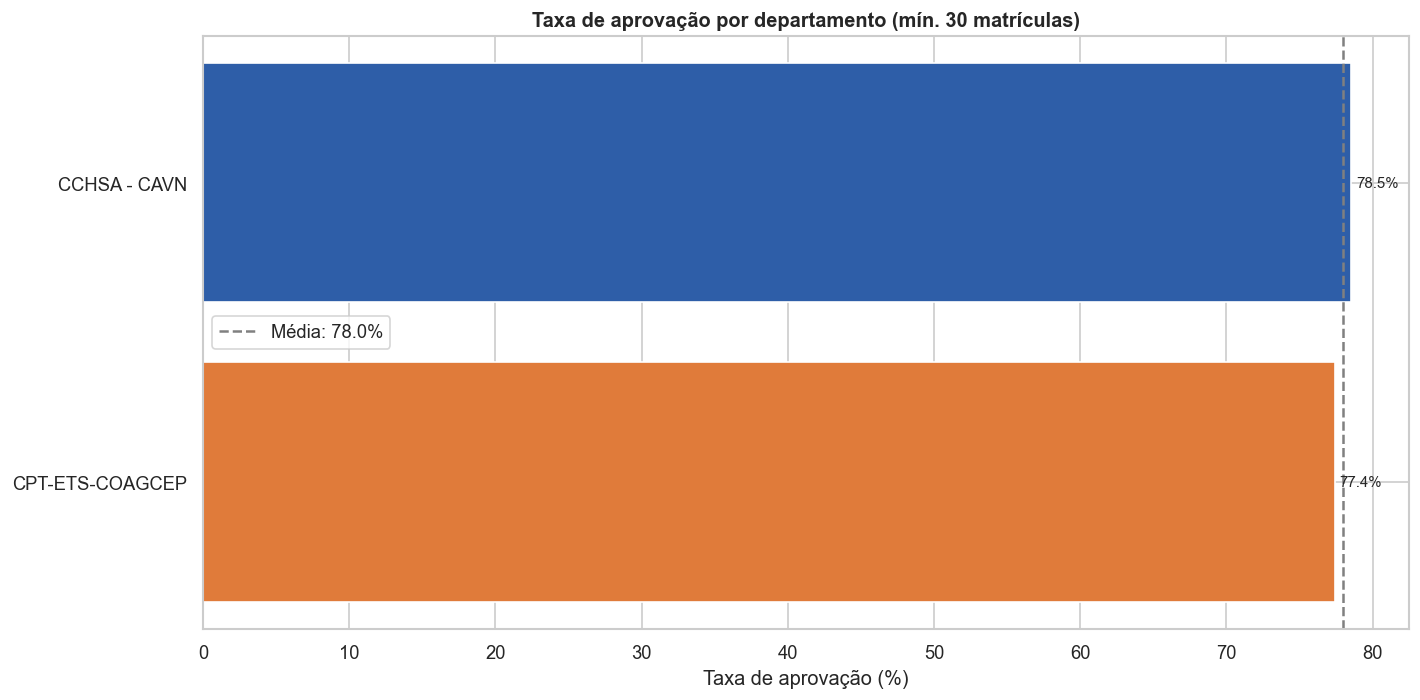

In [39]:
MIN_DEP = 30

if 'sigla_centro' in df_modelo.columns:
    gc = df_modelo.groupby('sigla_centro').agg(n=('target', 'count'), taxa_sucesso=('target', 'mean')).reset_index()
    gc = gc[gc['n'] >= MIN_DEP].sort_values('taxa_sucesso')
    gc['taxa_aprov_pct'] = gc['taxa_sucesso'] * 100
    fig, ax = plt.subplots(figsize=(10, max(4, len(gc) * 0.35)))
    colors = ['#2E5EA8' if v >= gc['taxa_aprov_pct'].mean() else '#E07B3A' for v in gc['taxa_aprov_pct']]
    ax.barh(gc['sigla_centro'], gc['taxa_aprov_pct'], color=colors)
    ax.axvline(gc['taxa_aprov_pct'].mean(), color='gray', linestyle='--', label=f"Média: {gc['taxa_aprov_pct'].mean():.1f}%")
    ax.set_xlabel('Taxa de aprovação (%)')
    ax.set_title(f'Aprovação por centro (n ≥ {MIN_DEP} matrículas)', fontweight='bold')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig('img/fig_centros_aprovacao.png', dpi=150, bbox_inches='tight')
    plt.show()

if 'sigla_departamento' in df_modelo.columns:
    taxa_dept = df_modelo.groupby('sigla_departamento').agg(
        taxa_sucesso=('target', 'mean'), total=('target', 'count')
    ).reset_index()
    taxa_dept = taxa_dept[taxa_dept['total'] >= MIN_DEP].sort_values('taxa_sucesso')
    taxa_dept['taxa_sucesso'] *= 100
    fig, ax = plt.subplots(figsize=(12, max(6, len(taxa_dept) * 0.4)))
    colors = ['#2E5EA8' if v >= taxa_dept['taxa_sucesso'].mean() else '#E07B3A' for v in taxa_dept['taxa_sucesso']]
    bars = ax.barh(taxa_dept['sigla_departamento'], taxa_dept['taxa_sucesso'], color=colors)
    ax.axvline(taxa_dept['taxa_sucesso'].mean(), color='gray', linestyle='--', lw=1.5,
               label=f"Média: {taxa_dept['taxa_sucesso'].mean():.1f}%")
    ax.set_xlabel('Taxa de aprovação (%)')
    ax.set_title(f'Taxa de aprovação por departamento (mín. {MIN_DEP} matrículas)', fontweight='bold')
    ax.legend()
    for bar, val in zip(bars, taxa_dept['taxa_sucesso']):
        ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2, f'{val:.1f}%', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('img/fig7_taxa_departamento.png', dpi=150, bbox_inches='tight')
    plt.show()

## 7. Perfil do discente e associação com reprovação / insucesso

Gráficos por **taxa de aprovação** (equivalente a enxergar onde o insucesso é maior). Incluímos **idade**, **média geral** acumulada, **CH integralizada/pendente**, composição da carga na oferta e **primeiro período** após ingresso.

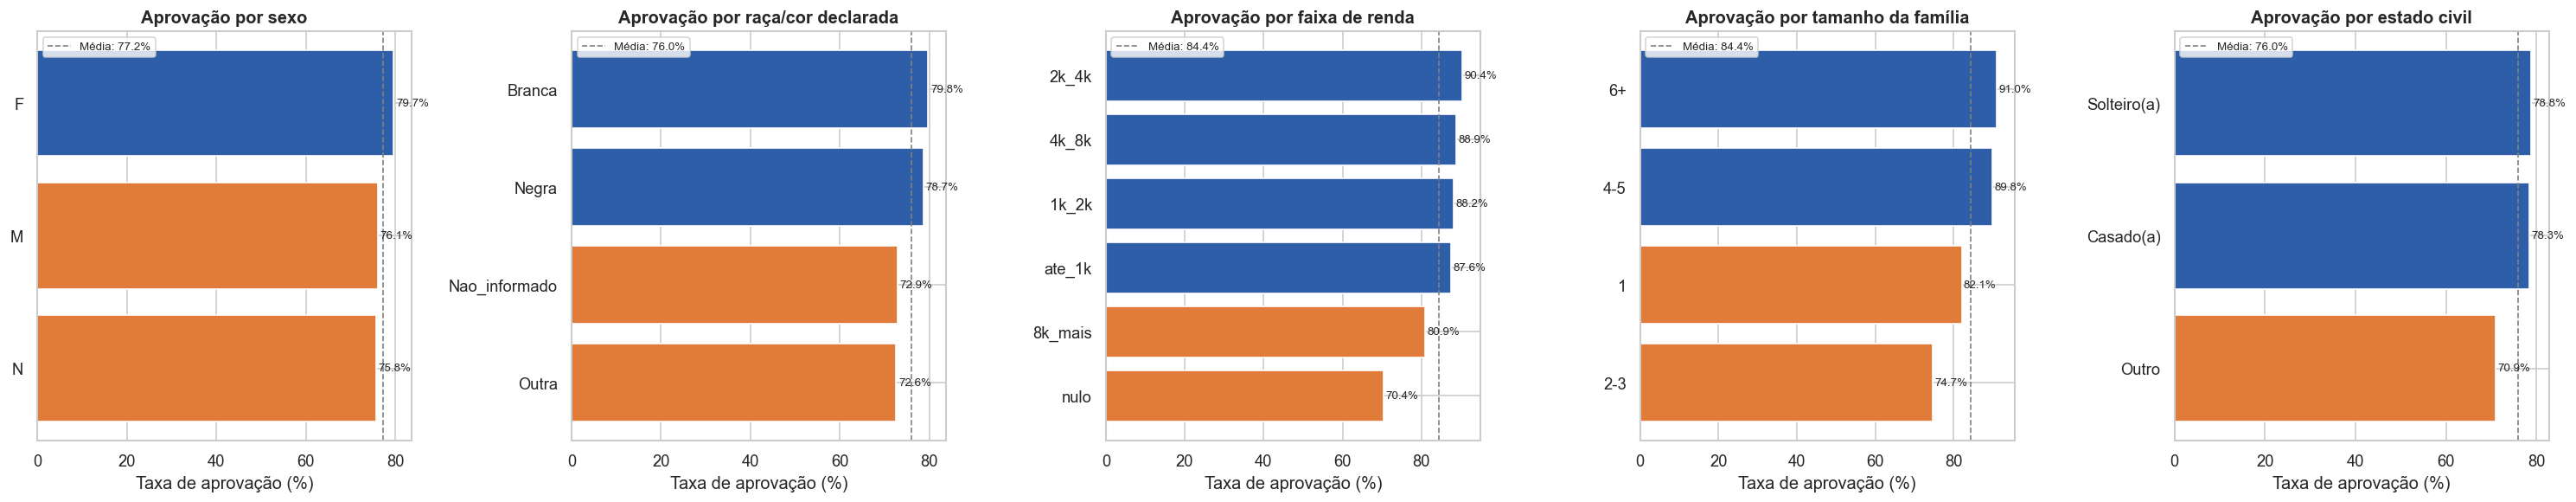

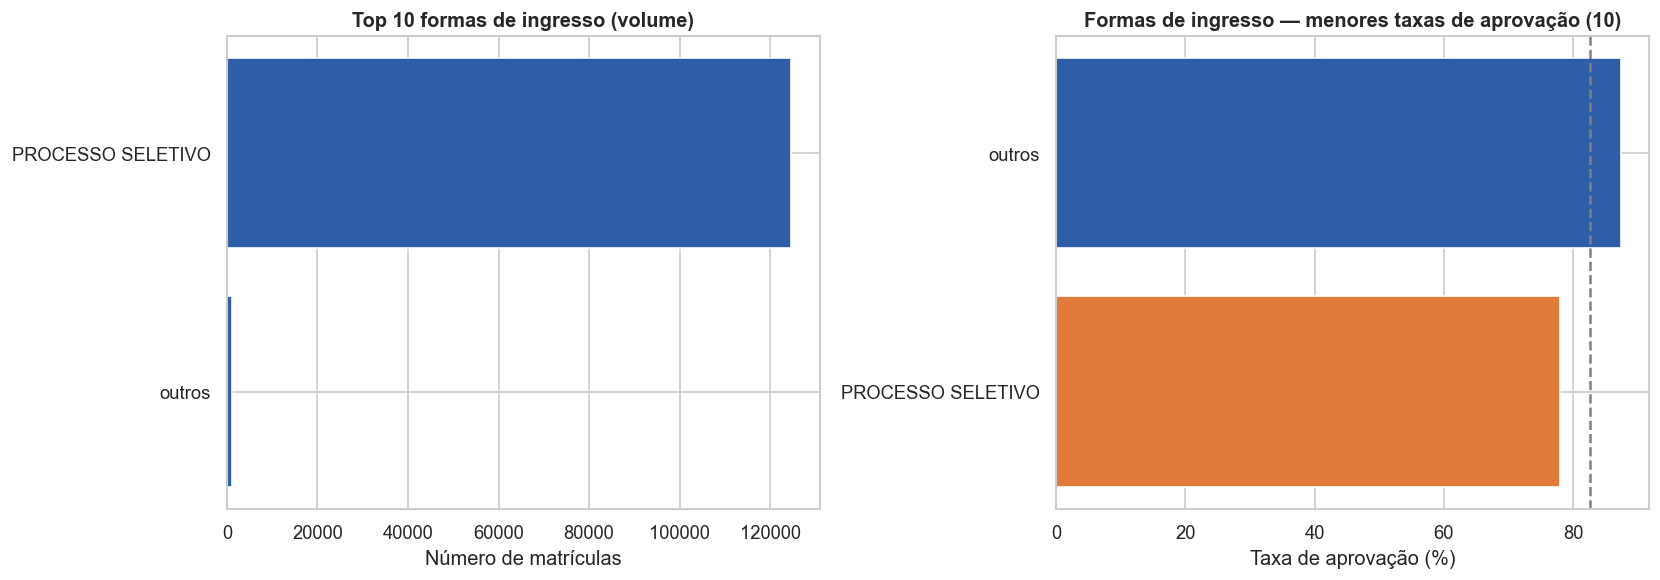

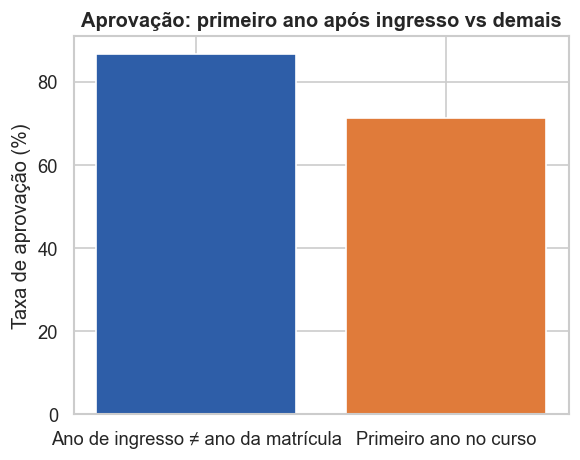

In [40]:
cols_perfil = [c for c in ['sexo', 'raca_declarada', 'faixa_renda_familiar', 'faixa_membros_familia', 'estado_civil'] if c in df_modelo.columns]
if cols_perfil:
    fig, axes = plt.subplots(1, len(cols_perfil), figsize=(5 * len(cols_perfil), 5))
    if len(cols_perfil) == 1:
        axes = [axes]
    titulos = {
        'sexo': 'Aprovação por sexo',
        'raca_declarada': 'Aprovação por raça/cor declarada',
        'faixa_renda_familiar': 'Aprovação por faixa de renda',
        'faixa_membros_familia': 'Aprovação por tamanho da família',
        'estado_civil': 'Aprovação por estado civil',
    }
    for ax, col in zip(axes, cols_perfil):
        taxa = df_modelo.groupby(col)['target'].mean().sort_values() * 100
        colors = ['#2E5EA8' if v >= taxa.mean() else '#E07B3A' for v in taxa.values]
        bars = ax.barh(taxa.index.astype(str).str[:40], taxa.values, color=colors)
        ax.axvline(taxa.mean(), color='gray', linestyle='--', linewidth=1, label=f'Média: {taxa.mean():.1f}%')
        ax.set_xlabel('Taxa de aprovação (%)')
        ax.set_title(titulos.get(col, col), fontweight='bold')
        ax.legend(fontsize=8)
        for bar, val in zip(bars, taxa.values):
            ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2, f'{val:.1f}%', va='center', fontsize=8)
    plt.tight_layout()
    plt.savefig('img/fig1_taxa_sucesso_perfil_aluno.png', dpi=150, bbox_inches='tight')
    plt.show()

if 'forma_ingresso' in df_modelo.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    forma_counts = df_modelo['forma_ingresso'].value_counts().head(10)
    axes[0].barh(forma_counts.index[::-1], forma_counts.values[::-1], color='#2E5EA8')
    axes[0].set_xlabel('Número de matrículas')
    axes[0].set_title('Top 10 formas de ingresso (volume)', fontweight='bold')
    taxa_ing = df_modelo.groupby('forma_ingresso')['target'].mean().sort_values().tail(10) * 100
    colors = ['#2E5EA8' if v >= taxa_ing.mean() else '#E07B3A' for v in taxa_ing.values]
    axes[1].barh(taxa_ing.index.astype(str).str[:45], taxa_ing.values, color=colors)
    axes[1].axvline(taxa_ing.mean(), color='gray', linestyle='--')
    axes[1].set_xlabel('Taxa de aprovação (%)')
    axes[1].set_title('Formas de ingresso — menores taxas de aprovação (10)', fontweight='bold')
    plt.tight_layout()
    plt.savefig('img/fig2_forma_ingresso.png', dpi=150, bbox_inches='tight')
    plt.show()

if 'primeiro_periodo' in df_modelo.columns:
    pp = df_modelo.groupby('primeiro_periodo')['target'].mean() * 100
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.bar(['Ano de ingresso ≠ ano da matrícula', 'Primeiro ano no curso'], [pp.get(0, 0), pp.get(1, 0)], color=['#2E5EA8', '#E07B3A'])
    ax.set_ylabel('Taxa de aprovação (%)')
    ax.set_title('Aprovação: primeiro ano após ingresso vs demais', fontweight='bold')
    plt.tight_layout()
    plt.savefig('img/fig_primeiro_periodo.png', dpi=150, bbox_inches='tight')
    plt.show()

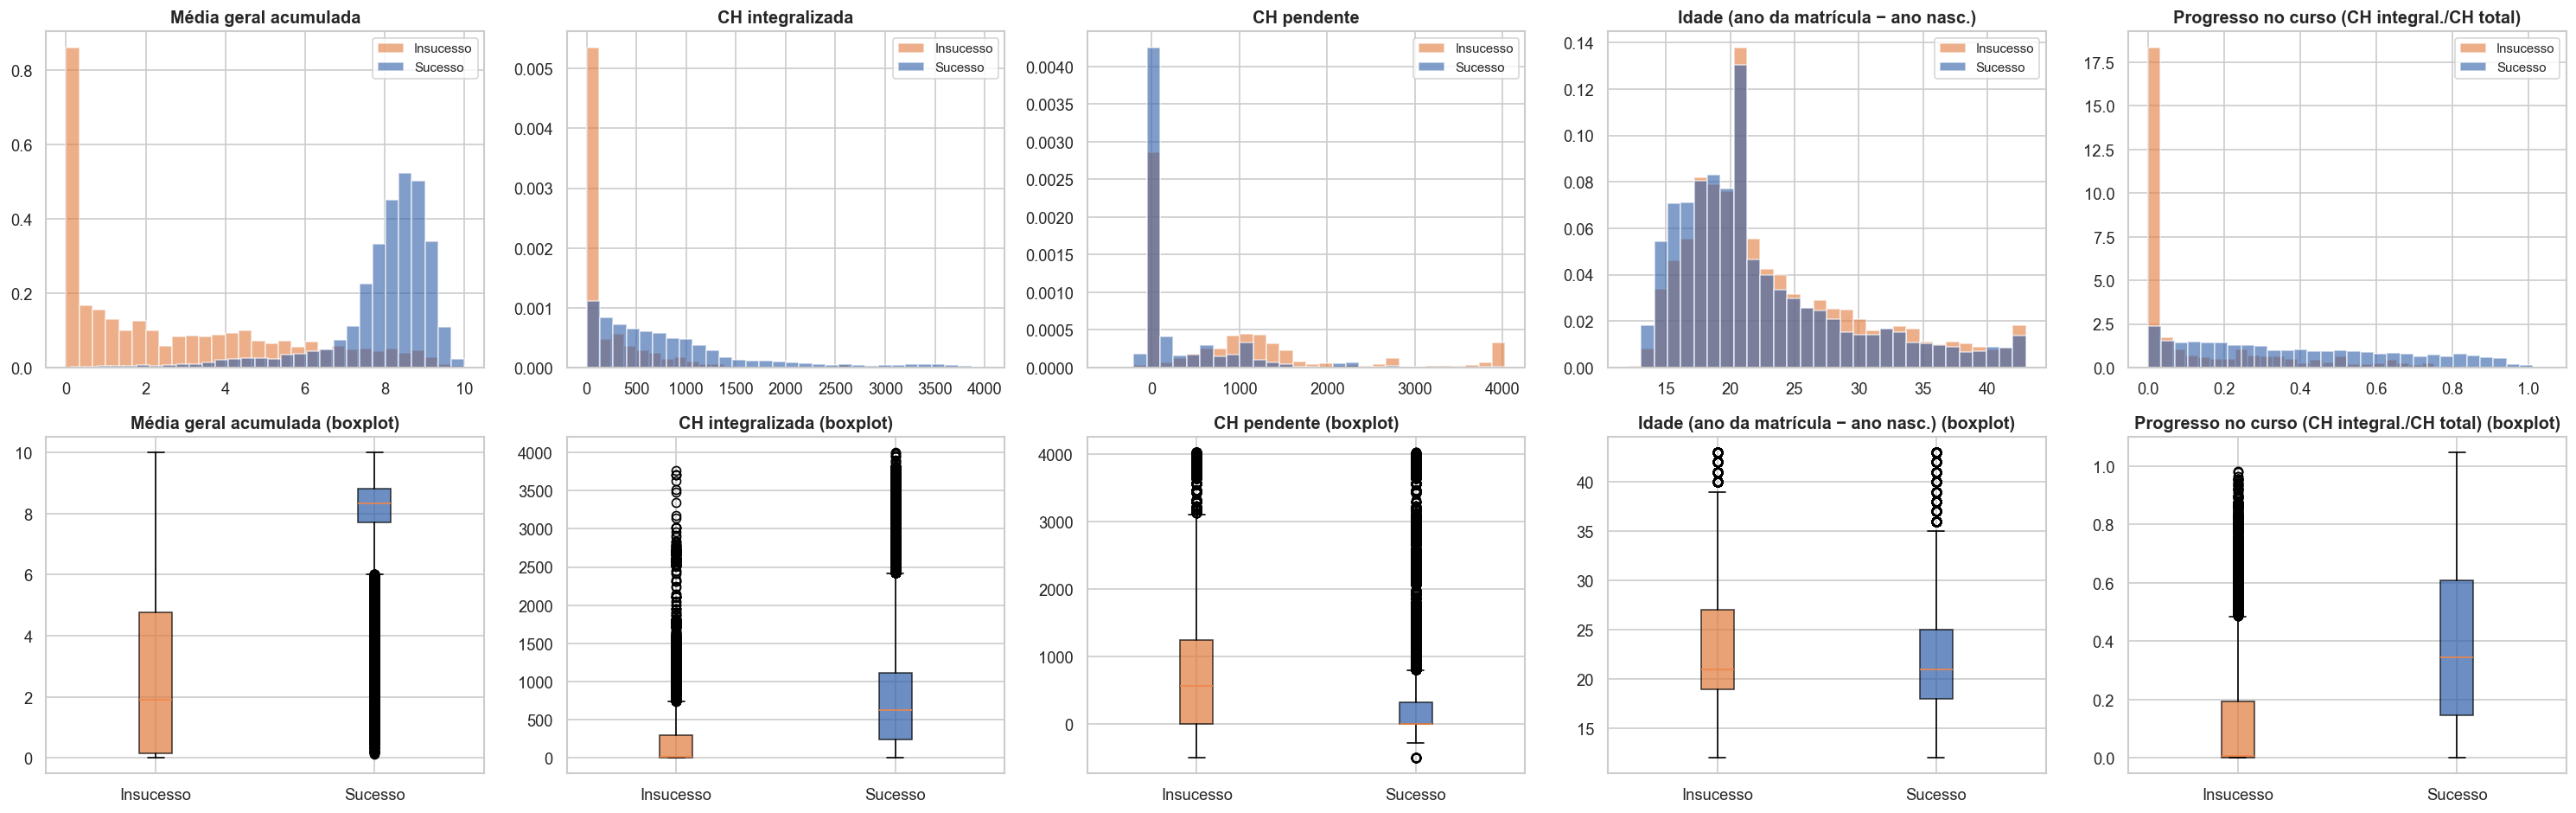

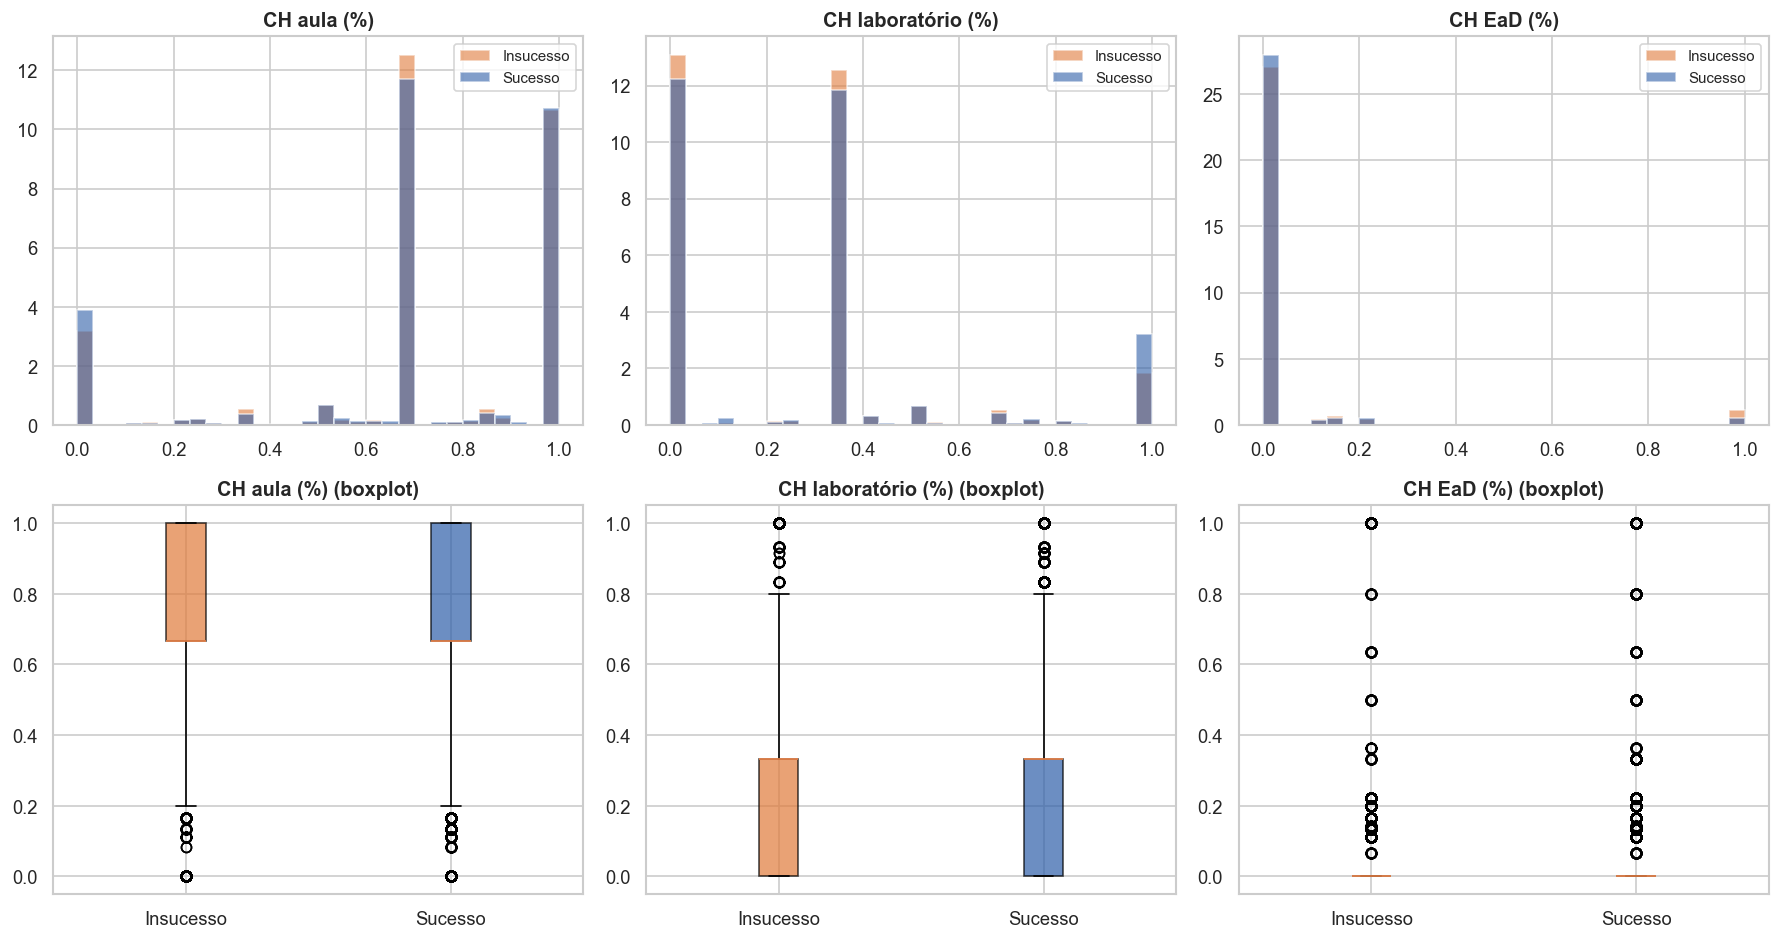

In [41]:
num_aluno = [(c, l) for c, l in [
    ('media_geral', 'Média geral acumulada'),
    ('ch_integralizada', 'CH integralizada'),
    ('ch_pendente', 'CH pendente'),
    ('idade', 'Idade (ano da matrícula − ano nasc.)'),
    ('progresso_atual_curso', 'Progresso no curso (CH integral./CH total)'),
] if c in df_modelo.columns]

if num_aluno:
    cols_p, labs_p = zip(*num_aluno)
    n = len(cols_p)
    fig, axes = plt.subplots(2, n, figsize=(5 * n, 8))
    if n == 1:
        axes = axes.reshape(2, 1)
    for i, (col, label) in enumerate(zip(cols_p, labs_p)):
        for cls, color, lbl in [(0, '#E07B3A', 'Insucesso'), (1, '#2E5EA8', 'Sucesso')]:
            subset = df_modelo[df_modelo['target'] == cls][col].dropna()
            axes[0, i].hist(subset, bins=30, alpha=0.6, color=color, label=lbl, density=True)
        axes[0, i].set_title(label, fontweight='bold')
        axes[0, i].legend(fontsize=9)
        data = [df_modelo[df_modelo['target'] == cls][col].dropna() for cls in [0, 1]]
        bp = axes[1, i].boxplot(data, patch_artist=True, tick_labels=['Insucesso', 'Sucesso'])
        for patch, color in zip(bp['boxes'], ['#E07B3A', '#2E5EA8']):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        axes[1, i].set_title(f'{label} (boxplot)', fontweight='bold')
    plt.tight_layout()
    plt.savefig('img/fig3_distribuicoes_numericas.png', dpi=150, bbox_inches='tight')
    plt.show()

num_ch = [(c, l) for c, l in [
    ('pct_carga_horaria_aula', 'CH aula (%)'),
    ('pct_carga_horaria_lab', 'CH laboratório (%)'),
    ('pct_carga_horaria_ead', 'CH EaD (%)'),
] if c in df_modelo.columns]
if num_ch:
    cols_p, labs_p = zip(*num_ch)
    n = len(cols_p)
    fig, axes = plt.subplots(2, n, figsize=(5 * n, 8))
    if n == 1:
        axes = axes.reshape(2, 1)
    for i, (col, label) in enumerate(zip(cols_p, labs_p)):
        for cls, color, lbl in [(0, '#E07B3A', 'Insucesso'), (1, '#2E5EA8', 'Sucesso')]:
            subset = df_modelo[df_modelo['target'] == cls][col].dropna()
            axes[0, i].hist(subset, bins=30, alpha=0.6, color=color, label=lbl, density=True)
        axes[0, i].set_title(label, fontweight='bold')
        axes[0, i].legend(fontsize=9)
        data = [df_modelo[df_modelo['target'] == cls][col].dropna() for cls in [0, 1]]
        bp = axes[1, i].boxplot(data, patch_artist=True, tick_labels=['Insucesso', 'Sucesso'])
        for patch, color in zip(bp['boxes'], ['#E07B3A', '#2E5EA8']):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        axes[1, i].set_title(f'{label} (boxplot)', fontweight='bold')
    plt.tight_layout()
    plt.savefig('img/fig3b_pct_carga_modalidades.png', dpi=150, bbox_inches='tight')
    plt.show()

## 8. Evolução temporal (a partir de 2015)

Volume de **matrículas** por ano e **taxa de reprovação** quando `target = 0` (insucesso agregado); a linha vermelha reflete toda falha modelada, não só REPROVADO.

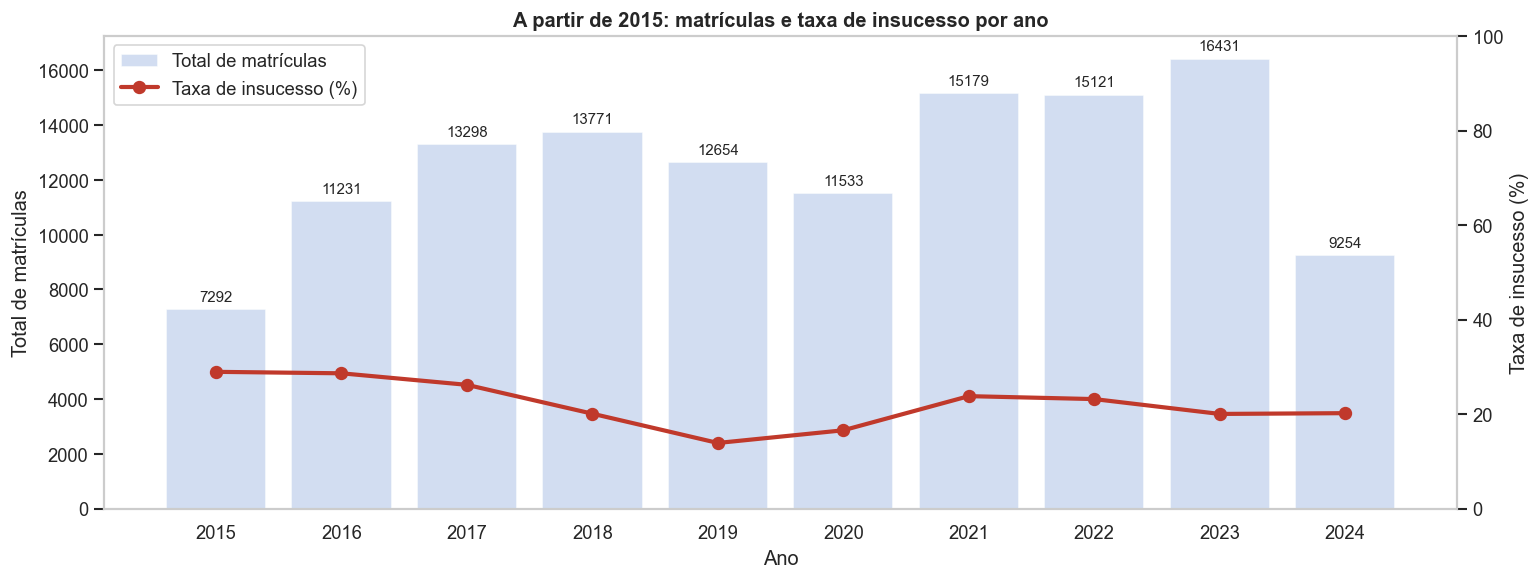

In [28]:
if {'ano', 'target'}.issubset(df_modelo.columns):
    df_plot = df_modelo.copy()
    df_plot['ano'] = pd.to_numeric(df_plot['ano'], errors='coerce')
    df_plot = df_plot[df_plot['ano'] >= 2015].copy()

    taxa_ano = (
        df_plot.groupby('ano', as_index=False)['target']
        .agg(taxa_sucesso='mean', total='count')
        .sort_values('ano')
    )
    taxa_ano['taxa_reprovacao'] = (1 - taxa_ano['taxa_sucesso']) * 100

    fig, ax1 = plt.subplots(figsize=(13, 5))
    ax2 = ax1.twinx()

    bars = ax1.bar(taxa_ano['ano'], taxa_ano['total'], color='#CBD8EF', alpha=0.85, label='Total de matrículas')
    ax2.plot(taxa_ano['ano'], taxa_ano['taxa_reprovacao'], 'o-', color='#C0392B', lw=2.5, ms=7, label='Taxa de insucesso (%)')

    ax1.grid(False)
    ax2.grid(False)
    ax1.bar_label(bars, labels=[f'{int(v)}' for v in taxa_ano['total']], padding=3, fontsize=9)

    ax1.set_xlabel('Ano')
    ax1.set_ylabel('Total de matrículas')
    ax2.set_ylabel('Taxa de insucesso (%)')
    ax2.set_ylim(0, 100)

    anos = taxa_ano['ano'].dropna().astype(int).tolist()
    ax1.set_xticks(anos)
    ax1.set_xticklabels(anos)

    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, loc='upper left')

    plt.title('A partir de 2015: matrículas e taxa de insucesso por ano', fontweight='bold')
    plt.tight_layout()
    plt.savefig('img/fig4_evolucao_reprovacao_2015.png', dpi=150, bbox_inches='tight')
    plt.show()

Frequência de situações por status_discente (n e % dentro do status):


,status_discente,situacao,n_matriculas,total_status,pct_dentro_status
0,ATIVO,APROVADO,12889,17855,72.19
5,ATIVO,REP. MEDIA E FALTA,2130,17855,11.93
6,ATIVO,REPROVADO,1574,17855,8.82
1,ATIVO,APROVEITADO,880,17855,4.93
7,ATIVO,TRANCADO,197,17855,1.10
3,ATIVO,DISPENSADO,88,17855,0.49
4,ATIVO,REP. FALTA,57,17855,0.32
2,ATIVO,DESISTENCIA,40,17855,0.22
8,ATIVO - FORMANDO,APROVADO,2467,2879,85.69
9,ATIVO - FORMANDO,APROVEITADO,311,2879,10.80


Percentual de cada situação dentro de cada status_discente (%):


situacao,APROV. C/ DISTINÇÃO,APROVADO,APROVEITADO,DESISTENCIA,DISPENSADO,REP. FALTA,REP. MEDIA E FALTA,REPROVADO,TRANCADO
status_discente,,,,,,,,,
ATIVO,0.00,72.19,4.93,0.22,0.49,0.32,11.93,8.82,1.10
ATIVO - FORMANDO,0.00,85.69,10.80,0.45,0.00,0.00,0.31,1.42,1.32
CANCELADO,0.02,40.49,1.50,0.40,0.34,0.45,17.53,30.27,8.98
CONCLUÍDO,0.00,94.56,3.38,0.10,0.36,0.05,0.29,0.80,0.46
TRANCADO,0.00,44.41,5.35,0.24,1.13,0.16,6.16,6.24,36.30


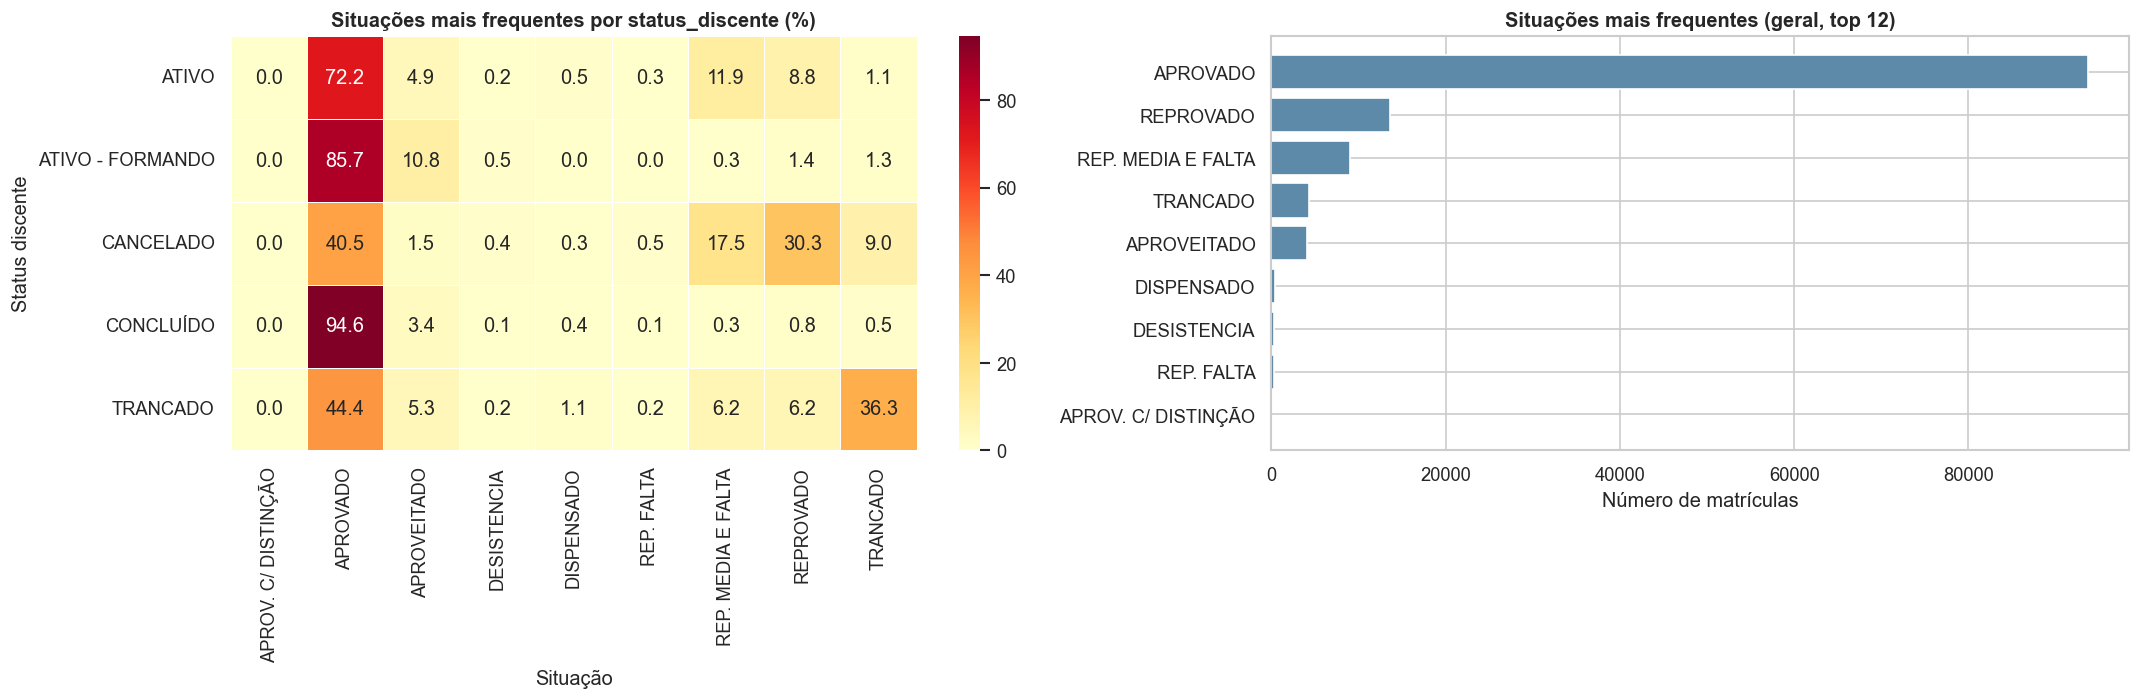

In [44]:
# Frequência de situacao por status_discente
# (distribuição por matrícula; sem agregação por ano)

if {'situacao', 'status_discente'}.issubset(df_modelo.columns):
    tmp = df_modelo.copy()
    tmp = tmp.dropna(subset=['situacao', 'status_discente'])

    freq = (
        tmp.groupby(['status_discente', 'situacao'], as_index=False)
        .size()
        .rename(columns={'size': 'n_matriculas'})
    )

    total_status = freq.groupby('status_discente', as_index=False)['n_matriculas'].sum()
    total_status = total_status.rename(columns={'n_matriculas': 'total_status'})
    freq = freq.merge(total_status, on='status_discente', how='left')
    freq['pct_dentro_status'] = (freq['n_matriculas'] / freq['total_status']) * 100

    print('Frequência de situações por status_discente (n e % dentro do status):')
    display(freq.sort_values(['status_discente', 'pct_dentro_status'], ascending=[True, False]).round(2))

    piv_pct = freq.pivot_table(
        index='status_discente',
        columns='situacao',
        values='pct_dentro_status',
        aggfunc='mean',
        fill_value=0,
    )
    piv_n = freq.pivot_table(
        index='status_discente',
        columns='situacao',
        values='n_matriculas',
        aggfunc='sum',
        fill_value=0,
    )

    print('Percentual de cada situação dentro de cada status_discente (%):')
    display(piv_pct.round(2))

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    sns.heatmap(piv_pct, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5, ax=axes[0])
    axes[0].set_title('Situações mais frequentes por status_discente (%)', fontweight='bold')
    axes[0].set_xlabel('Situação')
    axes[0].set_ylabel('Status discente')

    sit_total = tmp['situacao'].value_counts().head(12).iloc[::-1]
    axes[1].barh(sit_total.index.astype(str), sit_total.values, color='#5D8AA8')
    axes[1].set_xlabel('Número de matrículas')
    axes[1].set_title('Situações mais frequentes (geral, top 12)', fontweight='bold')

    plt.tight_layout()
    plt.savefig('img/fig_status_discente_situacao_frequencia.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Colunas necessárias não encontradas: situacao e status_discente.')

Taxa média de insucesso por status_discente (todas as matrículas):


,status_discente,n_matriculas,taxa_insucesso_media_pct
2,CANCELADO,37608,57.64
4,TRANCADO,1234,49.11
0,ATIVO,17855,22.39
1,ATIVO - FORMANDO,2879,3.51
3,CONCLUÍDO,66188,1.70


Taxa de insucesso (%) por ano e status_discente:


status_discente,ATIVO,ATIVO - FORMANDO,CANCELADO,CONCLUÍDO,TRANCADO
ano,,,,,
2015,NaN,0.00,57.73,0.66,NaN
2016,NaN,5.00,63.87,2.79,NaN
2017,NaN,4.00,65.42,2.42,NaN
2018,NaN,2.43,59.39,1.93,NaN
2019,29.41,1.37,44.19,1.42,29.03
2020,26.00,4.19,42.96,1.61,15.69
2021,42.19,3.01,55.57,1.57,21.95
2022,29.90,3.79,65.25,1.77,30.84
2023,19.44,9.00,66.28,0.86,58.79


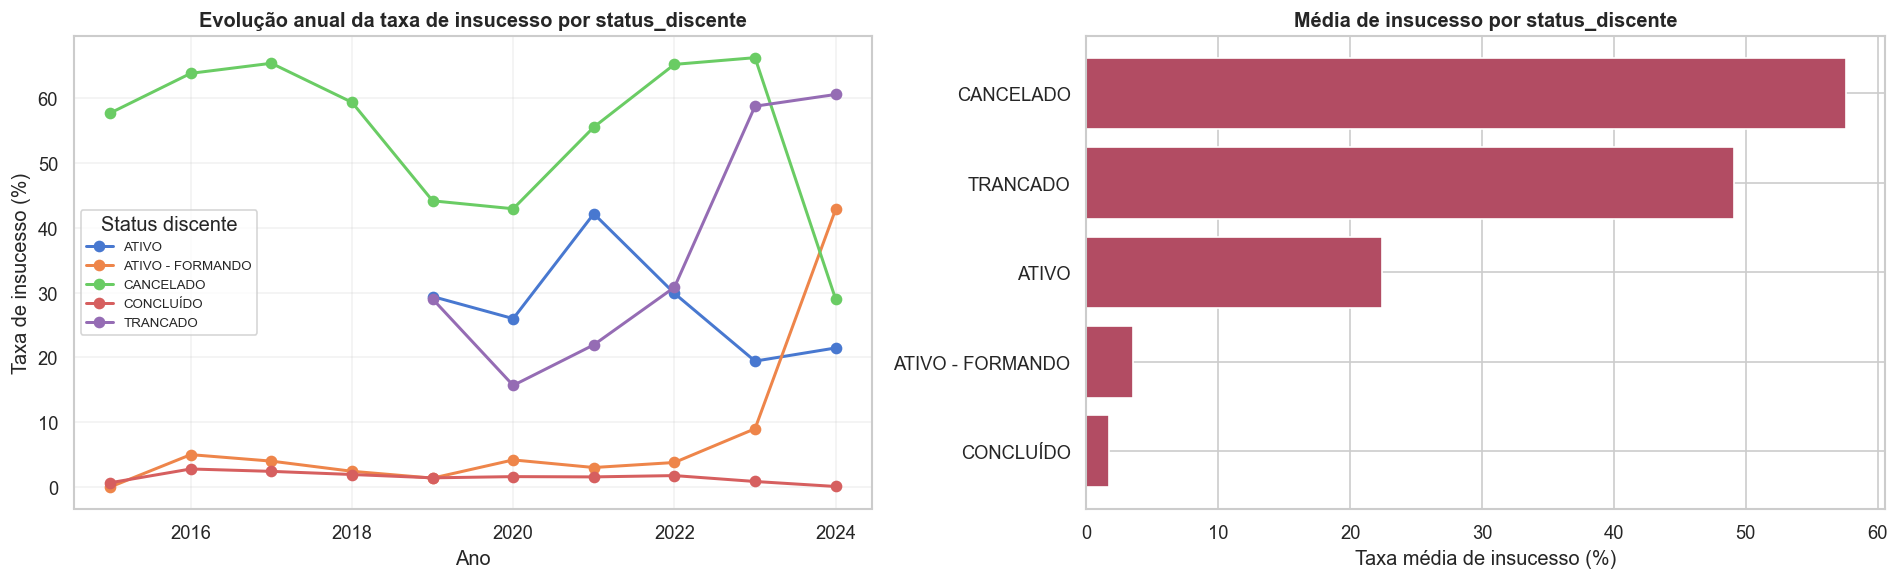

In [45]:
# Taxa de insucesso por status_discente e ano
# (insucesso = target 0, portanto inclui reprovação, trancamento, desistência etc.)

if {'ano', 'status_discente', 'target'}.issubset(df_modelo.columns):
    tmp = df_modelo.copy()
    tmp['ano'] = pd.to_numeric(tmp['ano'], errors='coerce')
    tmp = tmp.dropna(subset=['ano', 'status_discente', 'target'])

    # taxa de insucesso por ano x status (por matrícula)
    taxa_status_ano = (
        tmp.groupby(['ano', 'status_discente'], as_index=False)['target']
        .agg(taxa_sucesso='mean', n_matriculas='count')
    )
    taxa_status_ano['taxa_insucesso_pct'] = (1 - taxa_status_ano['taxa_sucesso']) * 100

    # média global por status_discente (ponderada por número de matrículas)
    media_status = (
        tmp.groupby('status_discente', as_index=False)['target']
        .agg(taxa_sucesso='mean', n_matriculas='count')
    )
    media_status['taxa_insucesso_media_pct'] = (1 - media_status['taxa_sucesso']) * 100
    media_status = media_status.sort_values('taxa_insucesso_media_pct', ascending=False)

    print('Taxa média de insucesso por status_discente (todas as matrículas):')
    display(media_status[['status_discente', 'n_matriculas', 'taxa_insucesso_media_pct']].round(2))

    # tabela ano x status
    piv = taxa_status_ano.pivot_table(
        index='ano',
        columns='status_discente',
        values='taxa_insucesso_pct',
        aggfunc='mean'
    ).sort_index()
    print('Taxa de insucesso (%) por ano e status_discente:')
    display(piv.round(2))

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # evolução anual por status
    for col in piv.columns:
        axes[0].plot(piv.index, piv[col], marker='o', linewidth=1.8, label=str(col))
    axes[0].set_xlabel('Ano')
    axes[0].set_ylabel('Taxa de insucesso (%)')
    axes[0].set_title('Evolução anual da taxa de insucesso por status_discente', fontweight='bold')
    axes[0].legend(title='Status discente', fontsize=8)
    axes[0].grid(alpha=0.25)

    # média por status
    m = media_status[['status_discente', 'taxa_insucesso_media_pct']]
    axes[1].barh(m['status_discente'].astype(str)[::-1], m['taxa_insucesso_media_pct'][::-1], color='#B24C63')
    axes[1].set_xlabel('Taxa média de insucesso (%)')
    axes[1].set_title('Média de insucesso por status_discente', fontweight='bold')

    plt.tight_layout()
    plt.savefig('img/fig_status_discente_ano_insucesso.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Colunas necessárias não encontradas: ano, status_discente e target.')

## 9. Perfil da base de docentes (cadastro institucional)

Visão **agregada** dos registros em `docentes.parquet` (não amarrada matricula a matricula). Útil para contextualizar oferta e vínculos — o efeito no desempenho do aluno é analisado na modelagem com features de departamento/ano.

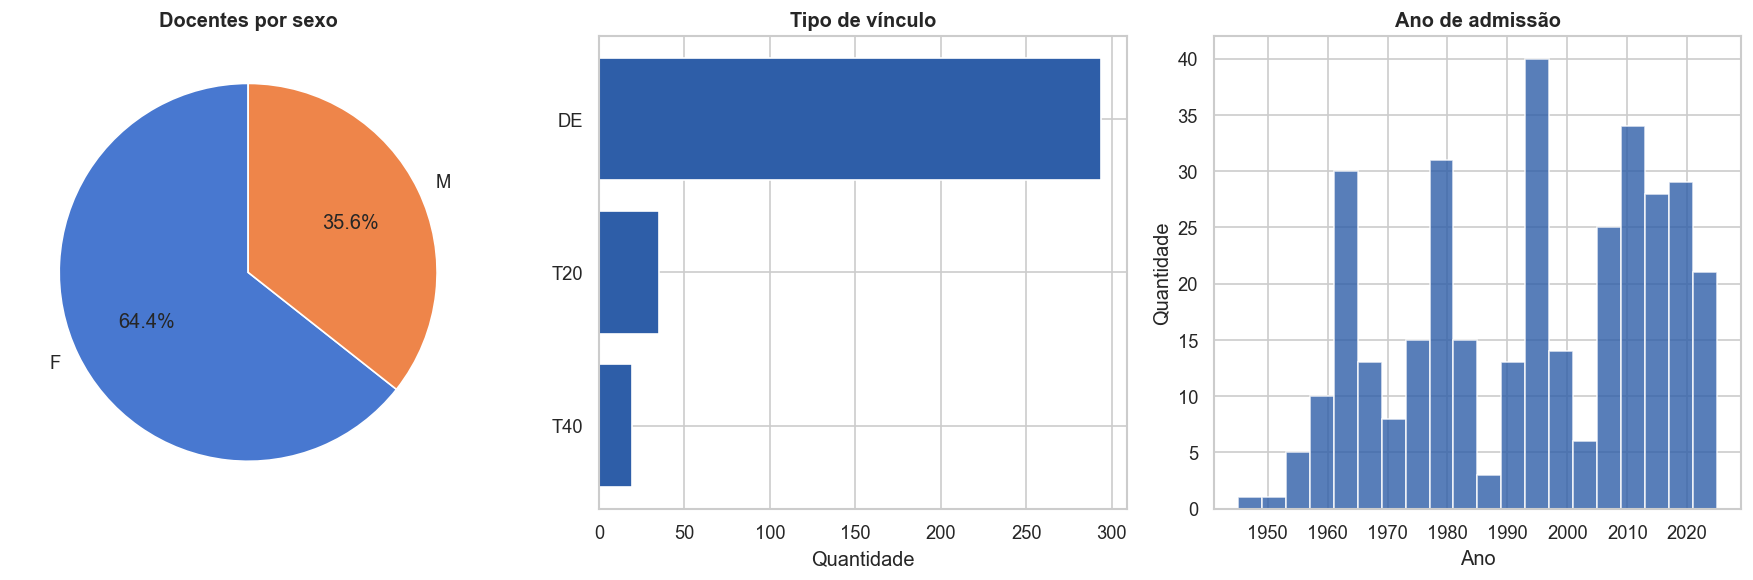

Total de registros docentes: 348


In [29]:
if docentes is not None and len(docentes):
    cols_doc = [c for c in ['sexo', 'tipo_vinculo', 'ano_admissao'] if c in docentes.columns]
    if cols_doc:
        fig, axes = plt.subplots(1, len(cols_doc), figsize=(5 * len(cols_doc), 5))
        if len(cols_doc) == 1:
            axes = [axes]
        for i, col in enumerate(cols_doc):
            ax = axes[i]
            if col == 'sexo':
                vc2 = docentes['sexo'].value_counts()
                ax.pie(vc2.values, labels=vc2.index, autopct='%1.1f%%', colors=sns.color_palette('muted', len(vc2)), startangle=90)
                ax.set_title('Docentes por sexo', fontweight='bold')
            elif col == 'tipo_vinculo':
                col_plot = 'tipo_vinculo_label' if 'tipo_vinculo_label' in docentes.columns else 'tipo_vinculo'
                vc2 = docentes[col_plot].value_counts().head(6)
                ax.barh(vc2.index[::-1], vc2.values[::-1], color='#2E5EA8')
                ax.set_xlabel('Quantidade')
                ax.set_title('Tipo de vínculo', fontweight='bold')
            elif col == 'ano_admissao':
                docentes['ano_admissao'].dropna().hist(bins=20, color='#2E5EA8', alpha=0.8, ax=ax)
                ax.set_xlabel('Ano')
                ax.set_ylabel('Quantidade')
                ax.set_title('Ano de admissão', fontweight='bold')
        plt.tight_layout()
        plt.savefig('img/fig8_perfil_docente.png', dpi=150, bbox_inches='tight')
        plt.show()
    print(f'Total de registros docentes: {len(docentes)}')
else:
    print('Arquivo docentes.parquet não encontrado ou vazio — seção ignorada.')

## 10. Cruzamentos e correlações

Heatmap **sexo × raça** para aprovação; matriz de correlação nas variáveis **numéricas** do CSV (interpretar com cuidado: mistura de escalas e variáveis derivadas).

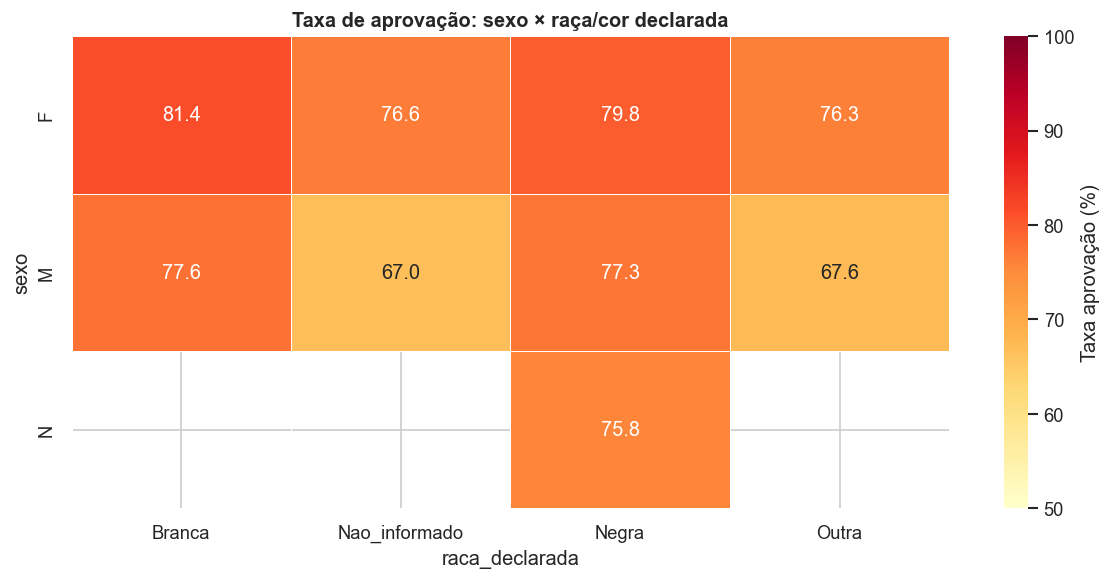

In [30]:
if {'sexo', 'raca_declarada', 'target'}.issubset(df_modelo.columns):
    pivot = df_modelo.groupby(['sexo', 'raca_declarada'])['target'].mean().unstack() * 100
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax, linewidths=0.5,
                vmin=50, vmax=100, cbar_kws={'label': 'Taxa aprovação (%)'})
    ax.set_title('Taxa de aprovação: sexo × raça/cor declarada', fontweight='bold')
    plt.tight_layout()
    plt.savefig('img/fig9_analise_alvo_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

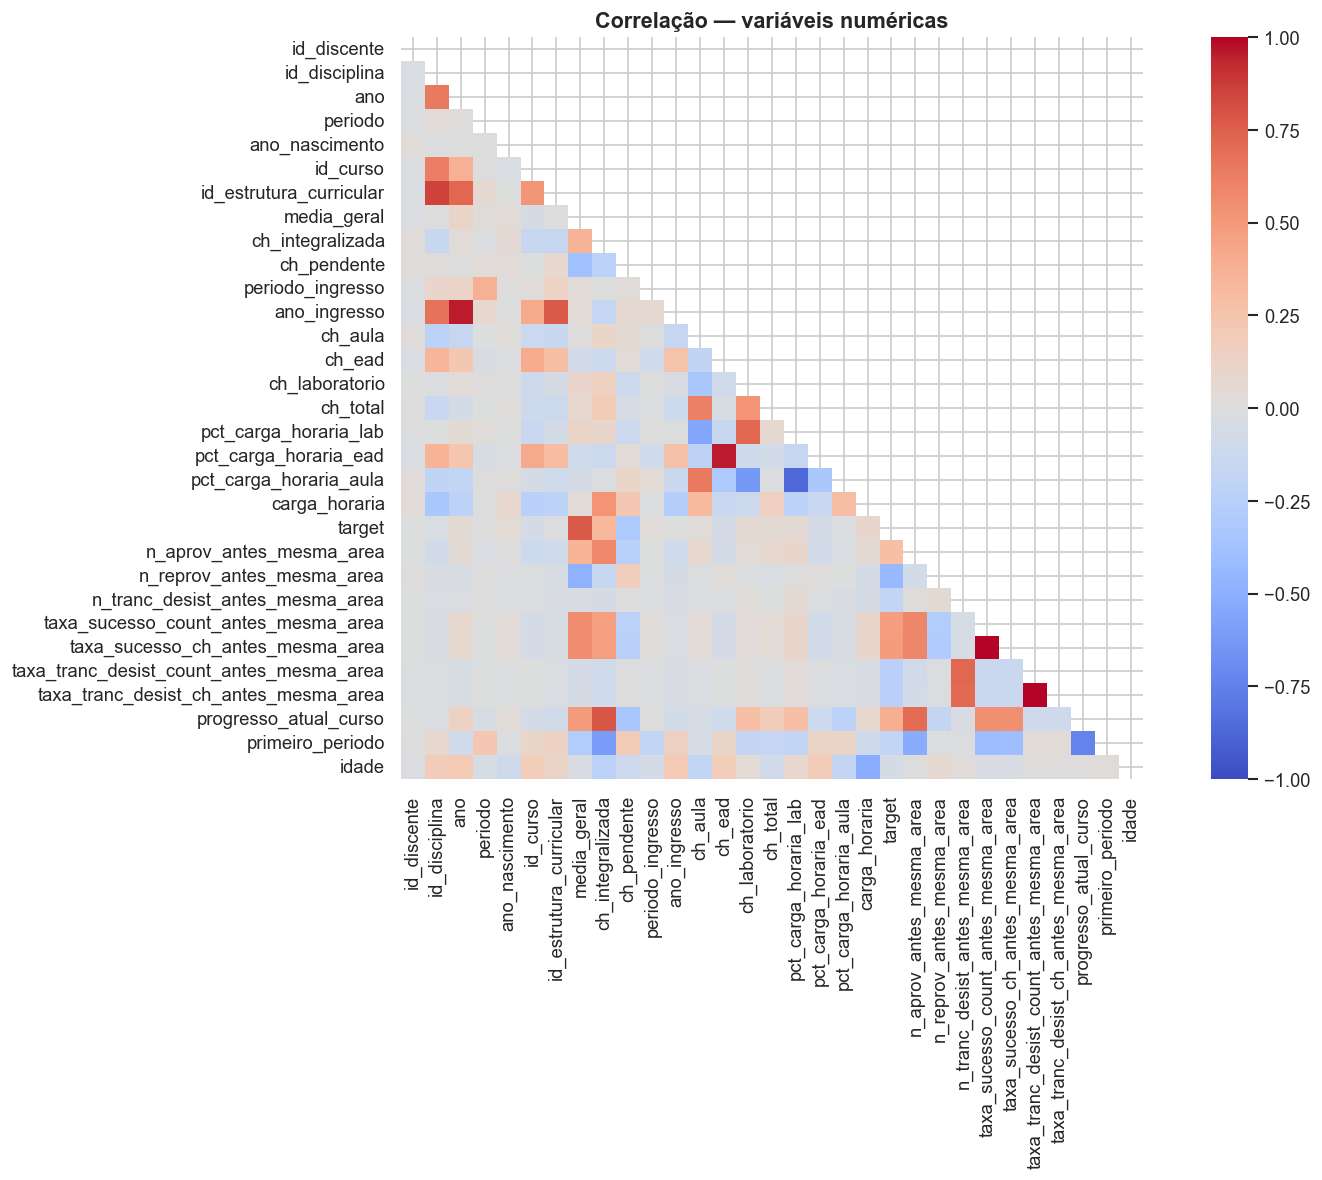

In [31]:
num_cols = df_modelo.select_dtypes(include='number').columns.tolist()
if len(num_cols) > 1:
    corr_matrix = df_modelo[num_cols].corr(numeric_only=True)
    fig, ax = plt.subplots(figsize=(14, 10))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, fmt='.2f', cmap='coolwarm', square=True, ax=ax, vmin=-1, vmax=1)
    ax.set_title('Correlação — variáveis numéricas', fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.savefig('img/fig10_correlacao.png', dpi=150, bbox_inches='tight')
    plt.show()